In [1]:
# Basic imports
import os
import numpy as np
from copy import deepcopy
import time
import glob
from functools import partial
from pprint import pprint
import astropy
from astropy.wcs import WCS
from astropy.io import fits
from astropy import stats
from astropy.nddata import Cutout2D
import pandas as pd
import matplotlib.pyplot as plt
from astropy.visualization.wcsaxes import WCSAxes
import matplotlib.cm as cm
import pyregion

from pyregion.mpl_helper import properties_func_default
from photutils.detection import DAOStarFinder, find_peaks
from photutils.aperture import CircularAperture
from matplotlib.colors import SymLogNorm, LogNorm, Normalize, TwoSlopeNorm
from astropy.wcs.utils import pixel_to_skycoord
from matplotlib import colors
from pathlib import Path
#from cut2d import *
from SFstarred.cut2d import *

/home/felipe/miniconda3/envs/SFstarred/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import h5py
from starred.deconvolution.deconvolution import Deconv, setup_model
from starred.deconvolution.loss import Loss as decLoss
from starred.deconvolution.parameters import ParametersDeconv
from starred.utils.noise_utils import propagate_noise
from starred.optim.optimization import Optimizer
from starred.plots import plot_function as pltf

from starred.psf.psf import PSF, load_PSF_model
from starred.psf.loss import Loss
from starred.psf.parameters import ParametersPSF

from starred.utils import ds9reg
from starred.utils.noise_utils import propagate_noise
from starred.procedures.psf_routines import run_multi_steps_PSF_reconstruction

# if running on CPU, might as well use double precision:
#from jax.lib import xla_bridge
#if not (yourdevice := xla_bridge.get_backend().platform ) == 'gpu':
 #   from jax.config import config
  #  config.update("jax_enable_x64", True) #we require double digit precision
#print(f"You are running on {yourdevice}.")

In [3]:
%load_ext autoreload
%autoreload 2

# F160W

Statistical properties data raw 
 mean=0.21156104804072326
 median=0.2108461558818817
 std=0.010854605675334467
Using reference exposure time of 2196.932374 s
Stats wht (mean, std, max): 739.4049297993361 245.45070672311192 1463.039794921875
Re-normalized the WHT map.
Median afterwards: 1171.4146763912013


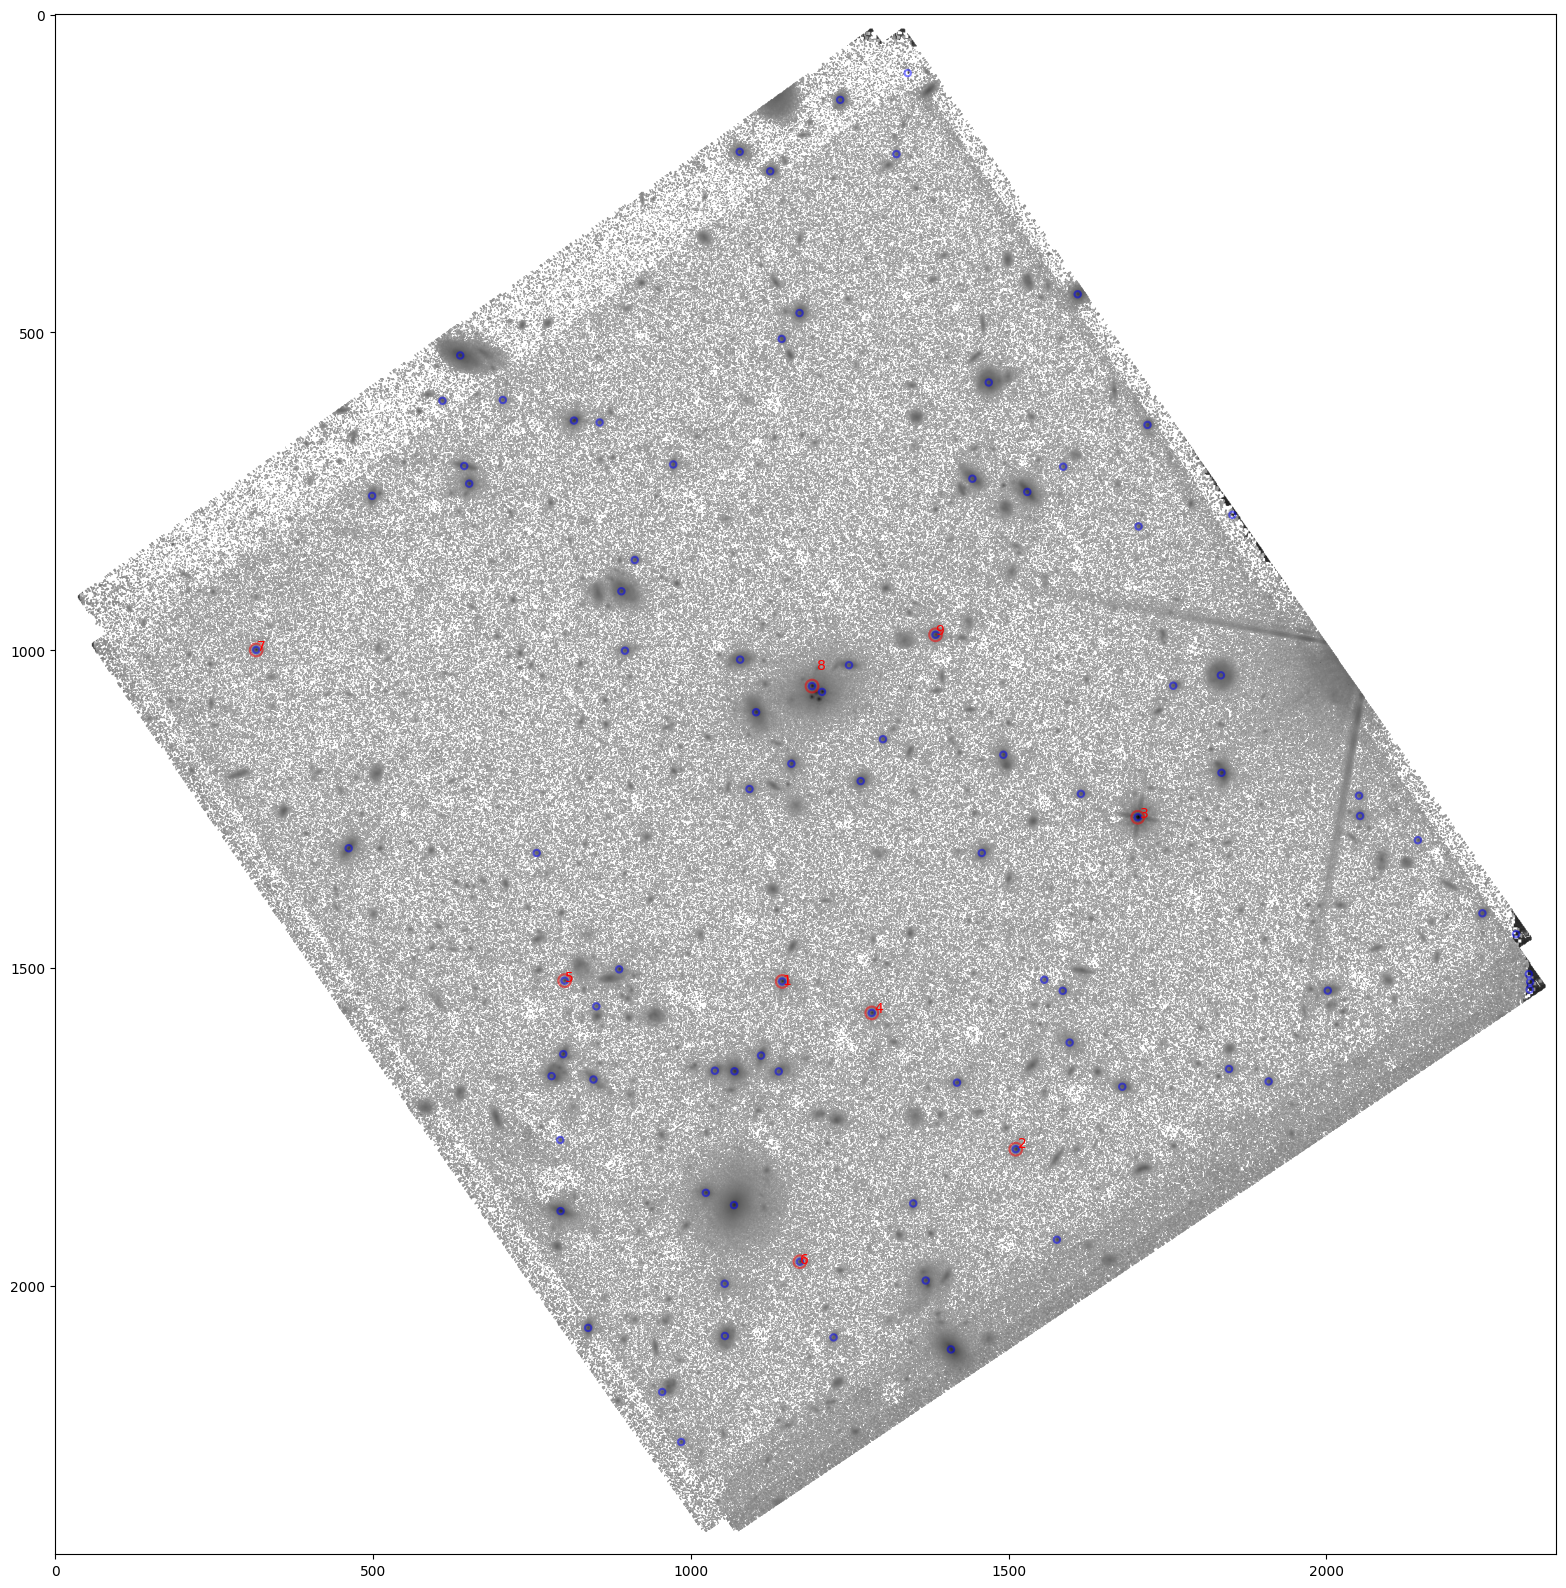

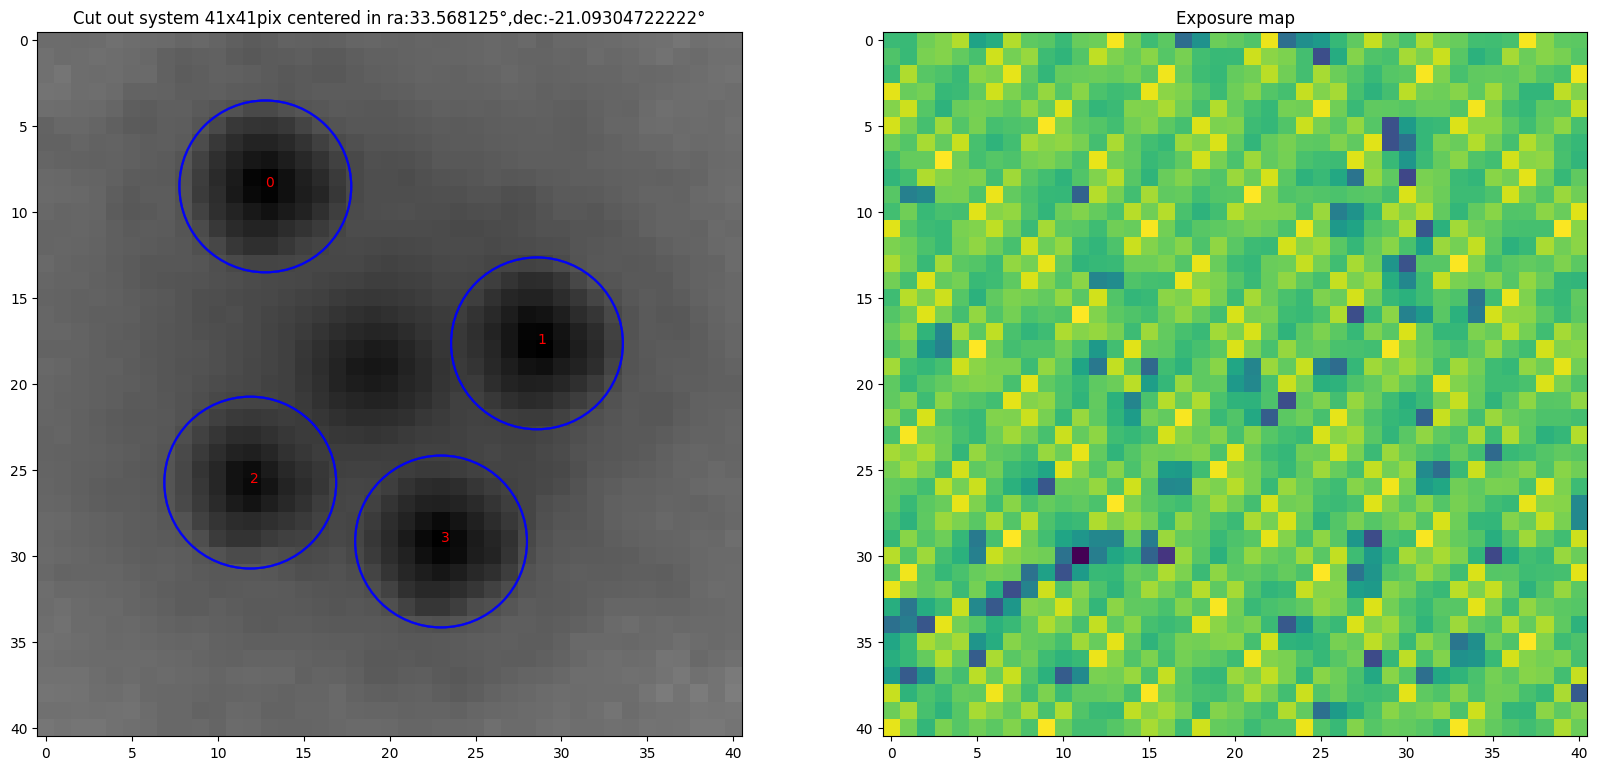

02h14m16.67s -21d04m59.04s


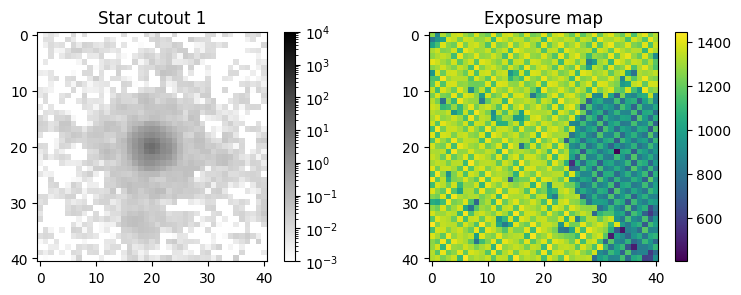

02h14m14.57s -21d04m37.92s


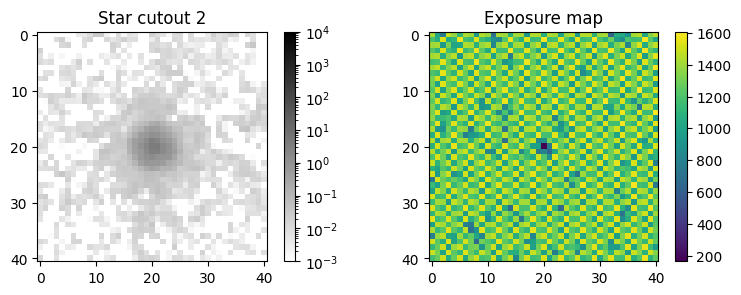

02h14m15.86s -21d04m55.07s


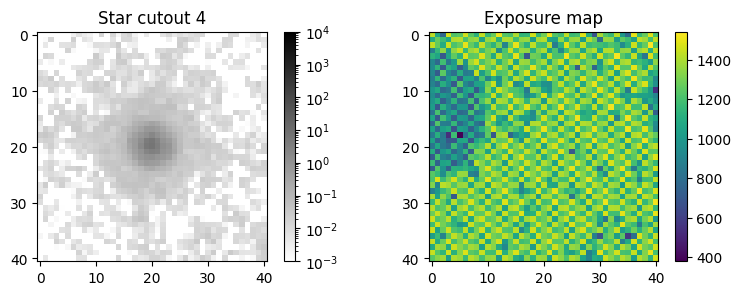

02h14m21.40s -21d05m40.76s


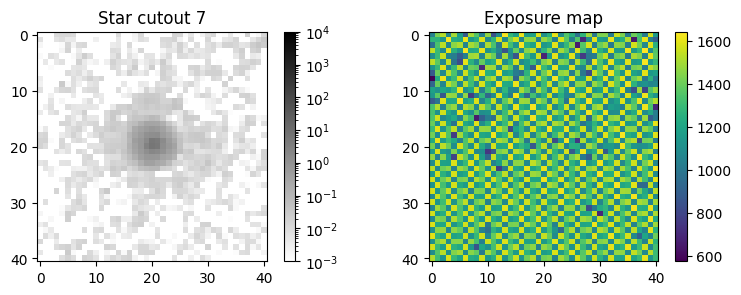

Mean sigma2_sky = 6.604516016905712e-05
Mean sigma2_target = 5.26240820361472e-05
Mean sigma2_sky = 6.552249837113776e-05
Mean sigma2_target = 4.968397031497812e-05
Mean sigma2_sky = 7.98251237234183e-05
Mean sigma2_target = 3.890424840676042e-05
Mean sigma2_sky = 4.182421996660111e-05
Mean sigma2_target = 3.001163286304209e-05

 Your results are save in data_products/F160W/cut_out_F160W.hdf5 



In [5]:
# Data directory
where_is_data = "HST_IMAGES_0214_2105"

# Data setup for starred
#remove_star: 5 (light contamination from other source), 8 (it is one of the QSO images); 9 (large residuals) 
Data_F160W,path_file=data_for_starred('WG0214-2105_F160W_drz_sci.fits',remove_star=[3,5,6,8,9],save=True,shift=[+0.00005, -0.00009],star_num_pix=41,make_plots=True)

In [32]:
# Setup parameters

# subsampling_factor control the resolution of the reconstructed psf
subsampling_factor = 2 #this can be increased for a better resolution, try 3 or 4; should be 3 for lenstronomy
n_iter_initial = 1000 #300
n_iter = 4000 

# increasing lambda_scales and lambda_hf will increase chi2 (they should be between 1 and 3)
lambda_scales = 3.0 # control the regularization strength for low frequencies 
lambda_hf = 3.0 # (increse this) control the regularization strength for high frequencies 
lambda_positivity = 1000. #0. #penalising term if the full psf have negative pixels. Leave it to 0. in most cases to save computationnal time.

convolution_method = 'scipy'#'fft'#'scipy'  #fft is better on CPU

# Stars normalize, norm factor and sigma_2 normalize by norm**2
data_norm_F160 = Data_F160W["data_cutout_norm"]
norm_F160W=Data_F160W["norm"]
sigma_2_norm_F160 = Data_F160W['sigma2_norm']

# number of stars
N = len(data_norm_F160)

# data dimensions
image_size = np.shape(data_norm_F160)[1]
image_size_up = image_size * subsampling_factor
print(np.shape(data_norm_F160))

(4, 41, 41)


In [33]:
sigma_2_norm_F160

array([[[0.0063161 , 0.00663291, 0.00675596, ..., 0.00683106,
         0.00733196, 0.0063161 ],
        [0.0063161 , 0.00703915, 0.00700651, ..., 0.00691338,
         0.0063161 , 0.0063161 ],
        [0.0063161 , 0.00655372, 0.00700735, ..., 0.00637908,
         0.00640574, 0.00718419],
        ...,
        [0.00637266, 0.0063161 , 0.00660325, ..., 0.0063161 ,
         0.0063161 , 0.00636421],
        [0.00683386, 0.00655041, 0.0068127 , ..., 0.0063161 ,
         0.0063161 , 0.00683536],
        [0.0063161 , 0.00640379, 0.0063161 , ..., 0.0063161 ,
         0.0063161 , 0.0063161 ]],

       [[0.00626612, 0.00630522, 0.00626612, ..., 0.00690529,
         0.00626612, 0.00626612],
        [0.00626612, 0.00626612, 0.00626612, ..., 0.00674573,
         0.00626612, 0.00626612],
        [0.00628302, 0.00626612, 0.00626612, ..., 0.00937544,
         0.00626612, 0.00626612],
        ...,
        [0.00648531, 0.00626612, 0.00626612, ..., 0.00639257,
         0.00630498, 0.00626612],
        [0.0

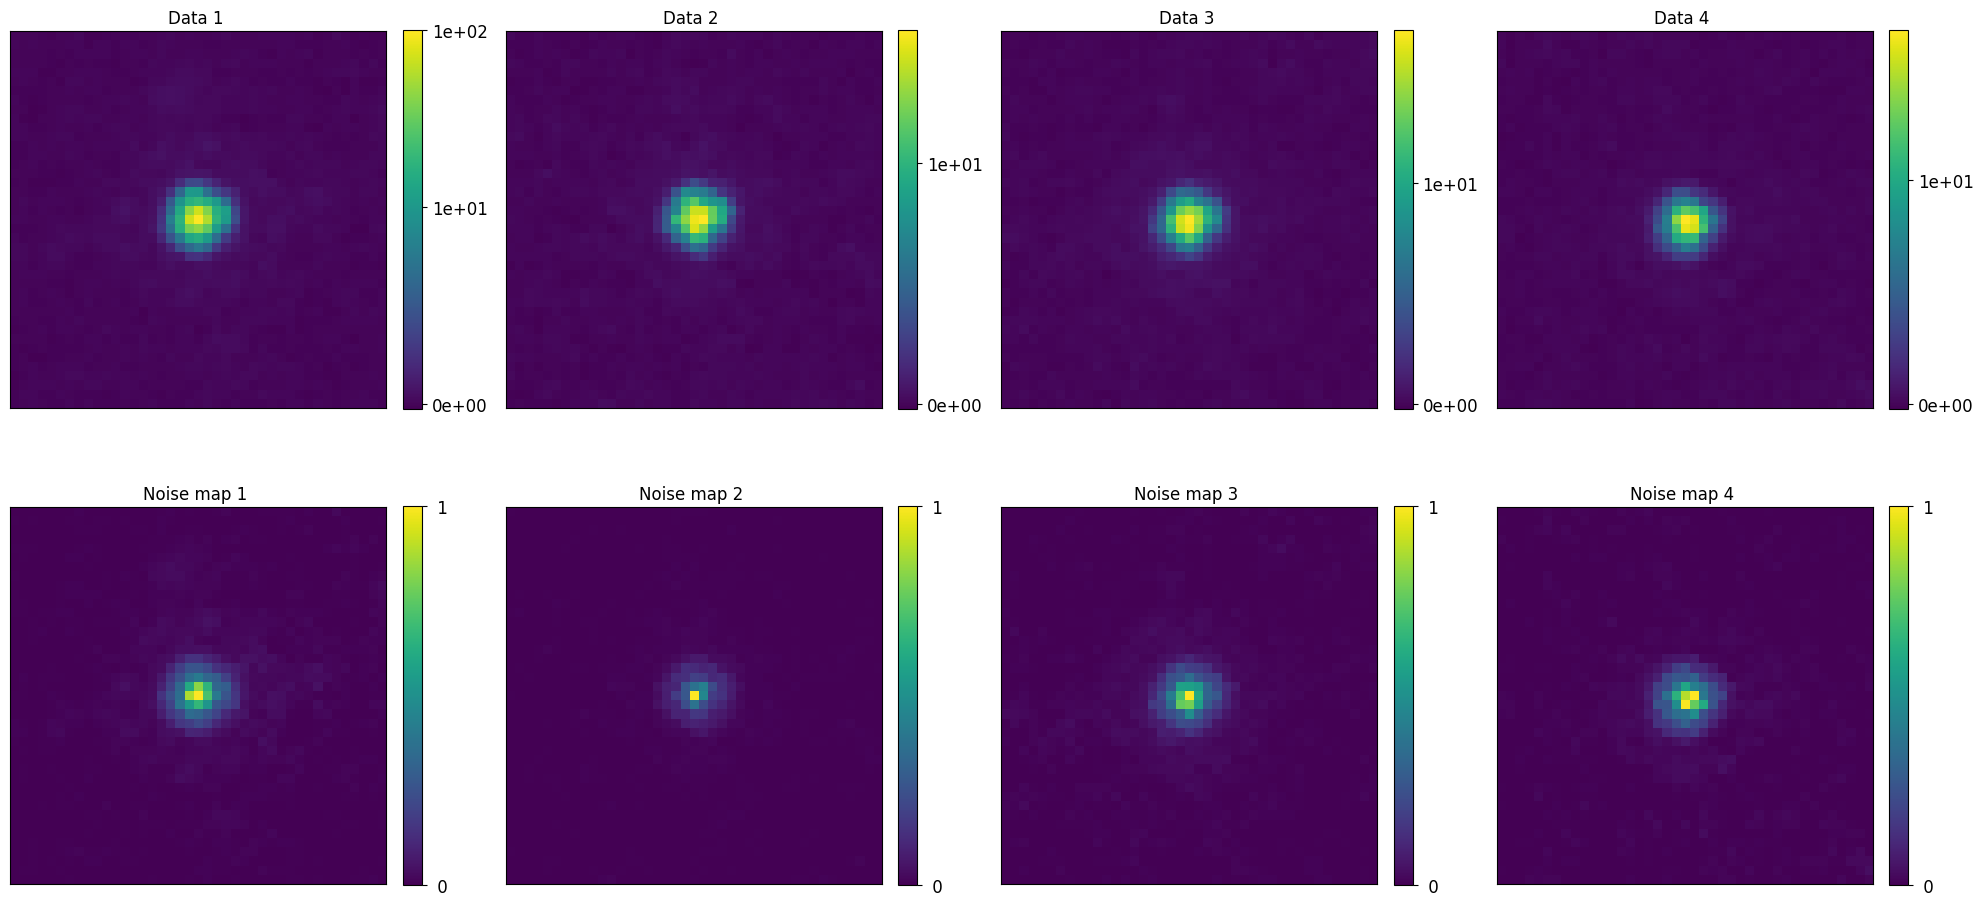

In [27]:
#removed star isn't plotted
fig = pltf.display_data(data_norm_F160, sigma_2 = sigma_2_norm_F160)

#### Method 1.

Initial Guess : {'kwargs_moffat': {'fwhm': 3.0, 'beta': 2.0, 'C': 45.2832145690918}, 'kwargs_gaussian': {'a': Array([62.79568 , 37.713856, 45.968914, 34.6544  ], dtype=float32), 'x0': array([0., 0., 0., 0.]), 'y0': array([0., 0., 0., 0.])}, 'kwargs_background': {'background': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float32), 'mean': Array([0., 0., 0., 0.], dtype=float32)}, 'kwargs_distortion': {'dilation_x': array([0., 0.]), 'dilation_y': array([0., 0.]), 'shear': array([0., 0.])}}
Moffat fit : {'kwargs_moffat': {'fwhm': Array([2.5876734], dtype=float32), 'beta': Array([2.8286233], dtype=float32), 'C': Array([45.29022], dtype=float32)}, 'kwargs_gaussian': {'a': Array([80.9035  , 50.268764, 59.02296 , 49.30878 ], dtype=float32), 'x0': Array([-0.04758552,  0.3823809 , -0.09182632,  0.2700391 ], dtype=float32), 'y0': Array([ 0.1860171 ,  0.21934329, -0.17632319, -0.3713923 ], dtype=float32)}, 'kwargs_background': {'background': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float32), 'mean

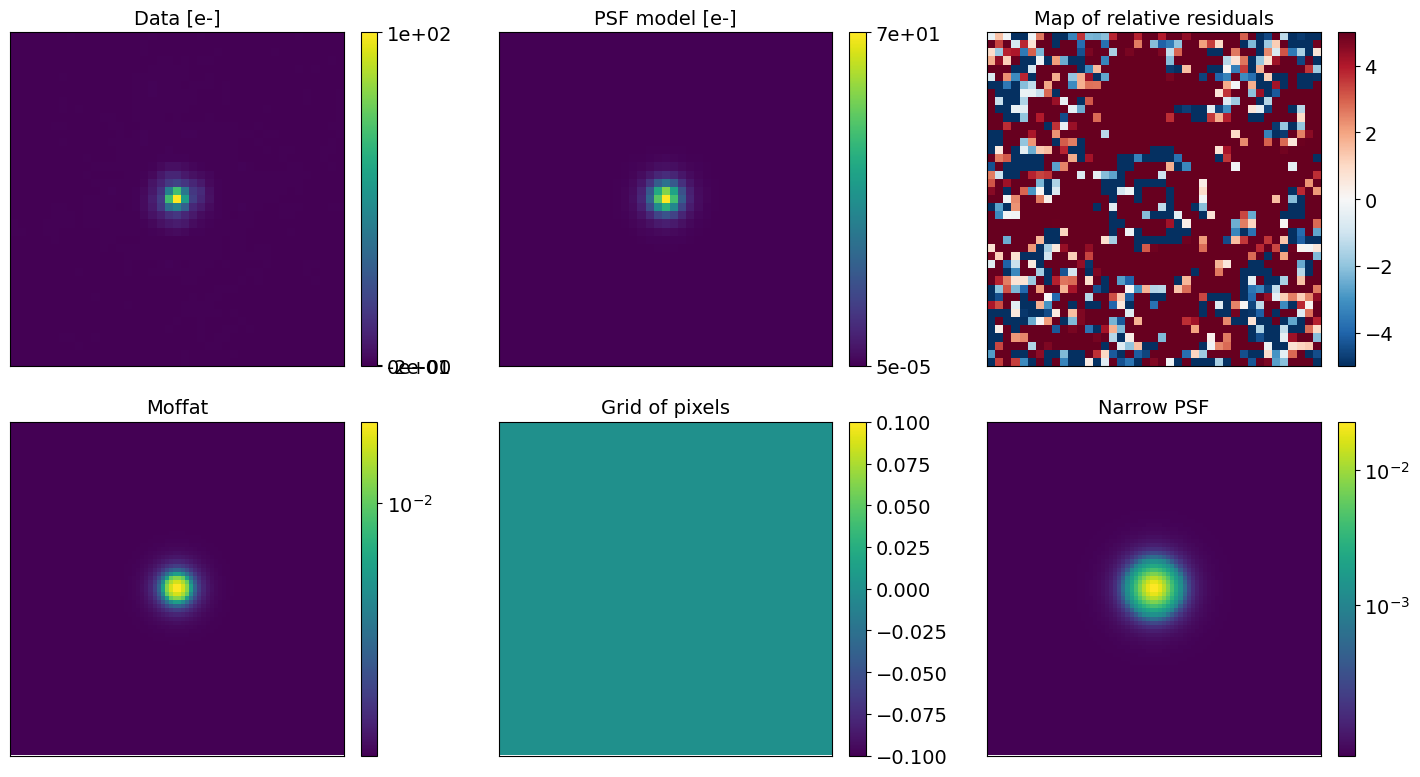

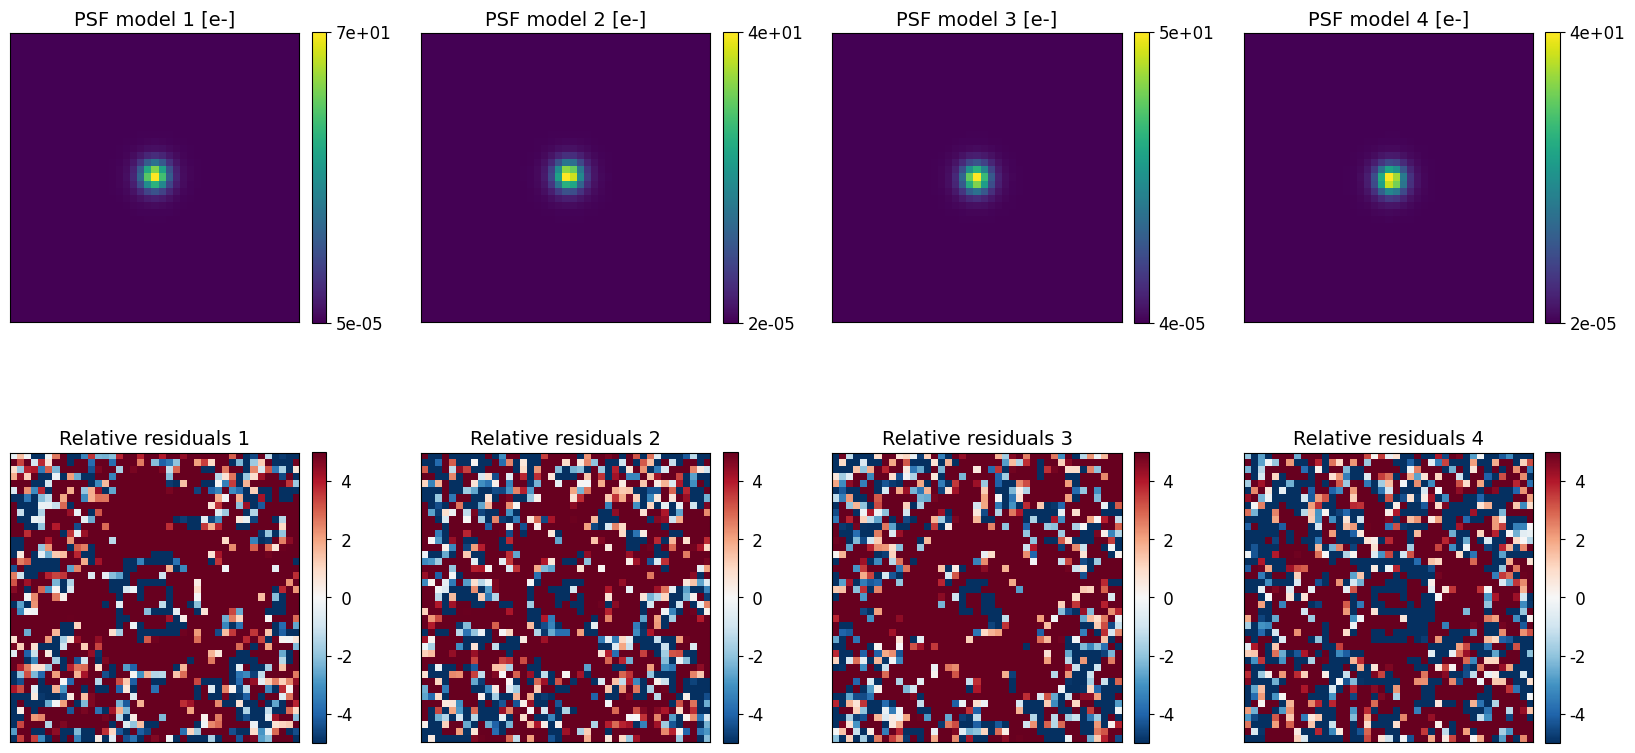

In [21]:
# Build the PSF model class
include_moffat = True
elliptical = False # if you want to fit ellitpical moffat or simply circular 
model = PSF(image_size=image_size, number_of_sources=N, 
            upsampling_factor=subsampling_factor, 
            convolution_method=convolution_method,
            include_moffat = include_moffat,
            elliptical_moffat = elliptical)

# Parameter initialization. 
####ERROR IN GUESS_FWHM_PIXELS#### kwargs_init, kwargs_fixed, kwargs_up, kwargs_down = model.smart_guess(data_norm_F160, fixed_background=True,guess_fwhm_pixels=3.97711804)
kwargs_init, kwargs_fixed, kwargs_up, kwargs_down = model.smart_guess(data_norm_F160, fixed_background=True)
#reset the position to 0 as the JWST is too complex for barycentric estimates
kwargs_init['kwargs_gaussian']['x0'] = np.array([0. for i in range(N)])
kwargs_init['kwargs_gaussian']['y0'] = np.array([0. for i in range(N)])
##############################################################################

print('Initial Guess :', kwargs_init) 

parameters = ParametersPSF(kwargs_init, kwargs_fixed, kwargs_up=kwargs_up, kwargs_down=kwargs_down)

# Moffat fitting and amplitude tunning 
optim_method = 'l-bfgs-b'
loss = Loss(data_norm_F160, model, parameters, sigma_2_norm_F160, N, regularization_terms='l1_starlet', 
            regularization_strength_scales=0, regularization_strength_hf=0, masks = None) 
optim = Optimizer(loss, parameters, method=optim_method)

optimiser_options = {'maxiter':6000, 
                     'restart_from_init':True}

best_fit, logL_best_fit, extra_fields, runtime = optim.minimize(**optimiser_options)
# Printing partial results
kwargs_partial = parameters.args2kwargs(best_fit)
print('Moffat fit :',kwargs_partial) 

fig2 = pltf.single_PSF_plot(model, data_norm_F160, sigma_2_norm_F160, kwargs_partial,masks=None, n_psf=0, units='e-')
fig3 = pltf.multiple_PSF_plot(model, data_norm_F160, sigma_2_norm_F160, kwargs_partial,masks=None, units='e-')

Mean noise level in each starlet scale: 
Scale 0 : 4.0455117
Scale 1 : 3.1446445
Scale 2 : 1.7939548
Scale 3 : 0.9104319
Scale 4 : 0.43462992
Scale 5 : 0.20030007
Scale 6 : 0.10472565


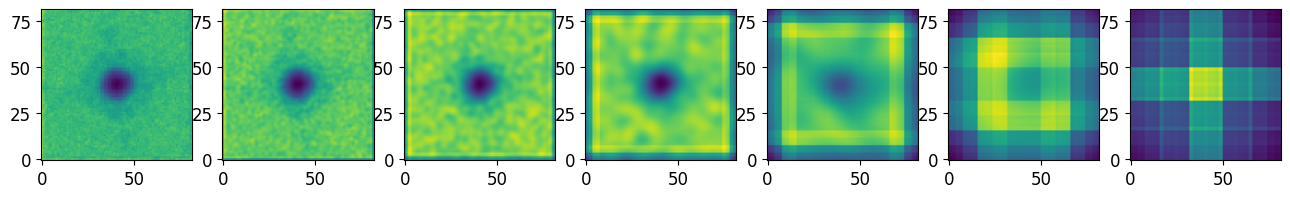

In [8]:
# compute noise level in starlet space, also propagate poisson noise
method_noise = "MC" #SLIT 
W = propagate_noise(model, np.sqrt(sigma_2_norm_F160), kwargs_partial, masks=None, wavelet_type_list=['starlet'], method=method_noise, num_samples=500,
             seed=1, likelihood_type='chi2', verbose=False, upsampling_factor=subsampling_factor, scaling_noise_ref = None)[0]

#This is a representation of your noise maps (background + Poisson) in the different starlet scales
gix, axs = plt.subplots(1, len(W), figsize=(16, 4))
print('Mean noise level in each starlet scale: ')
for i, l in enumerate(W):
    axs[i].imshow(l, origin='lower')
    print('Scale %i :'%i, np.mean(l))
plt.show()

In [9]:
regularize_full_psf = True #If True, regularise [m(x)+b(x)]. Regularise only the b(x) if False.
masks = None 
#  Release backgound, fix the moffat amplitude
kwargs_moffat_fixed = {'C':kwargs_partial['kwargs_moffat']['C']}

kwargs_fixed = {
    'kwargs_moffat': kwargs_moffat_fixed,
    'kwargs_gaussian': {},
    'kwargs_background': {},
    "kwargs_distortion":{}
}

parameters = ParametersPSF(kwargs_partial, kwargs_fixed, kwargs_up, kwargs_down)

loss = Loss(data_norm_F160, model, parameters, sigma_2_norm_F160, N, regularization_terms='l1_starlet',
            regularization_strength_scales=lambda_scales, regularization_strength_hf=lambda_hf,
            regularization_strength_positivity=lambda_positivity, W=W, regularize_full_psf=regularize_full_psf, masks=None)


optim = Optimizer(loss, parameters, method='adabelief')

kwargs_optim = {
                'max_iterations': 4000, 'min_iterations': None,
                'init_learning_rate': 3e-2, 'schedule_learning_rate': False,
                'restart_from_init': False, 'stop_at_loss_increase': False,
                'progress_bar': True, 'return_param_history': True
            }
best_fit, logL_best_fit, extra_fields, runtime = optim.minimize(**kwargs_optim)

optax.adabelief: 100%|██████████| 4000/4000 [00:52<00:00, 76.49it/s]


{'kwargs_moffat': {'fwhm': Array([1.0528355], dtype=float32), 'beta': Array([1.8448836], dtype=float32), 'C': Array([45.283234], dtype=float32)}, 'kwargs_gaussian': {'a': Array([435.2975 , 267.5495 , 305.98767, 252.0577 ], dtype=float32), 'x0': Array([-0.20048498,  0.21195857, -0.27221042,  0.1358352 ], dtype=float32), 'y0': Array([-0.04163023, -0.05895636, -0.42509863, -0.59689647], dtype=float32)}, 'kwargs_background': {'background': Array([-0.00424548,  0.00360035,  0.00724355, ..., -0.00366296,
       -0.00808966, -0.00126112], dtype=float32), 'mean': Array([-0.03525372, -0.02022084, -0.00717153, -0.04242177], dtype=float32)}, 'kwargs_distortion': {'dilation_x': Array([0., 0.], dtype=float32), 'dilation_y': Array([0., 0.], dtype=float32), 'shear': Array([0., 0.], dtype=float32)}}


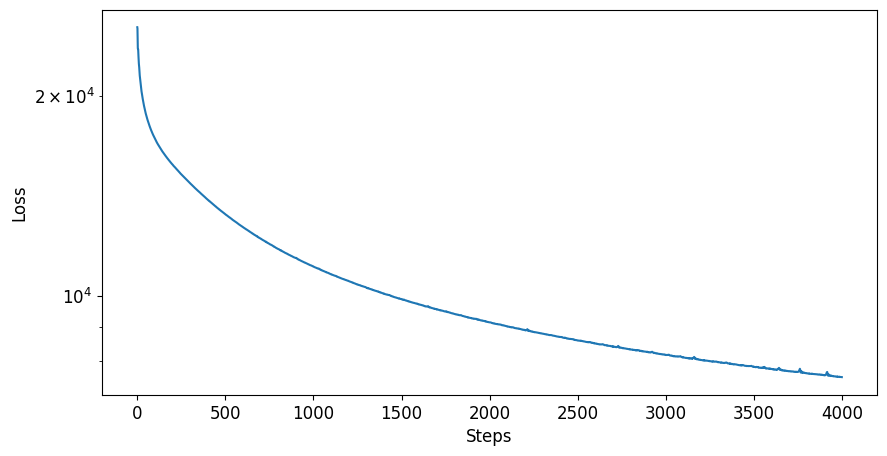

In [10]:
fig_loss = pltf.plot_loss(extra_fields['loss_history'])

kwargs_final = parameters.args2kwargs(best_fit)
print(kwargs_final)

Overall Reduced Chi2 : 1.3297407627105713


/tmp/ipykernel_43965/353186559.py:6: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.nan_to_num(np.log10(full_psf), nan=-10), origin='lower', vmin=-6, vmax=-2)


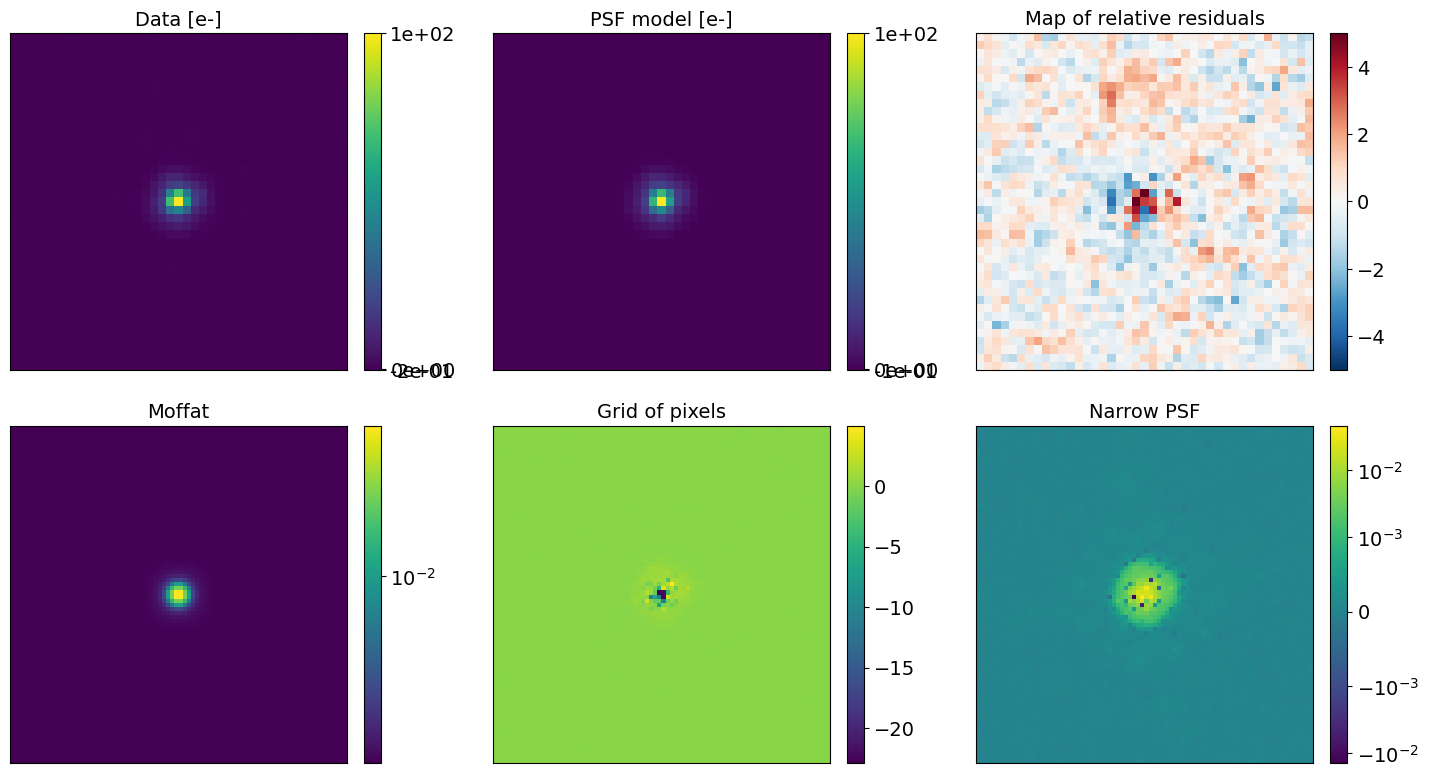

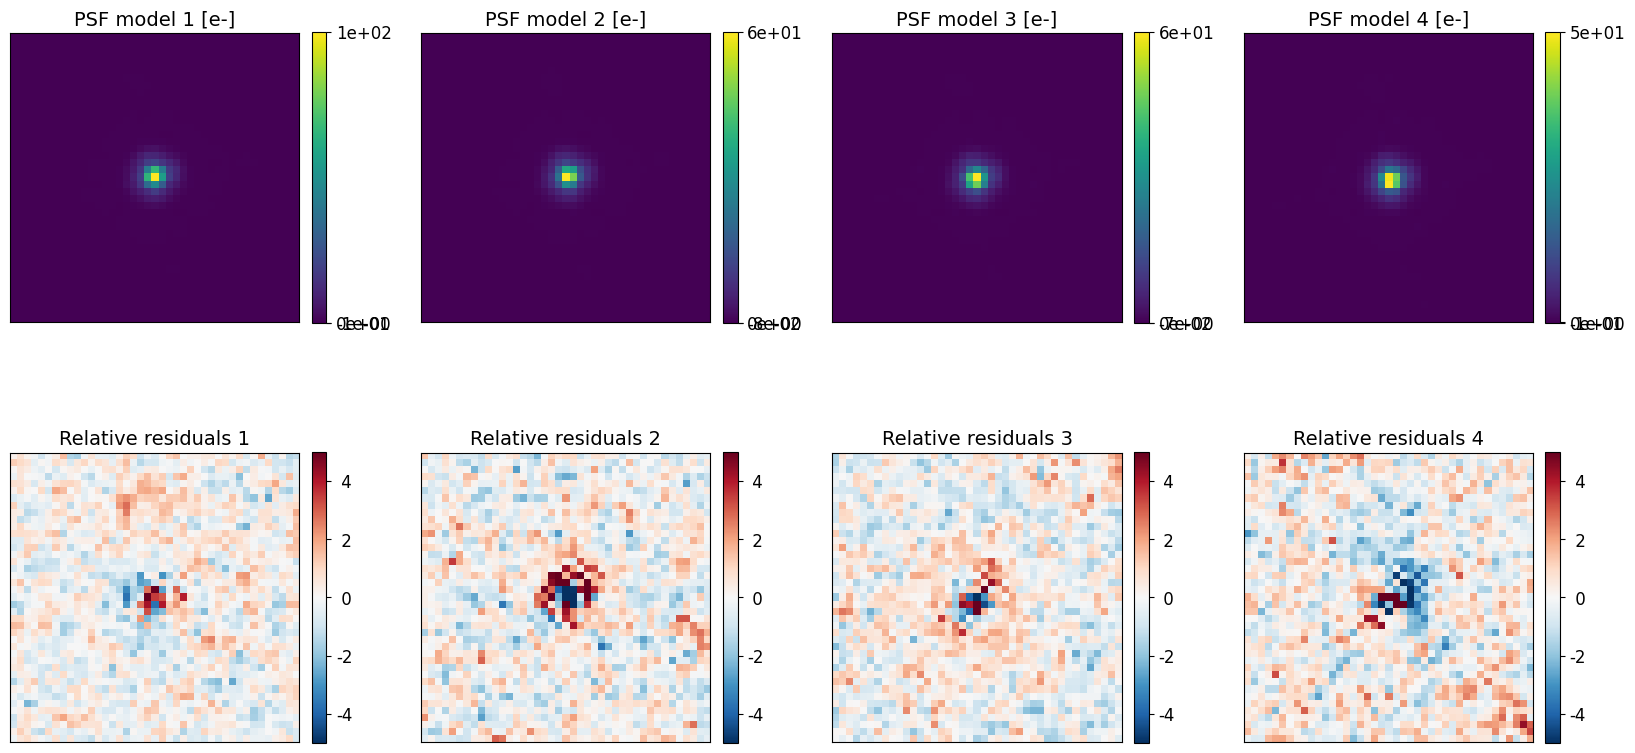

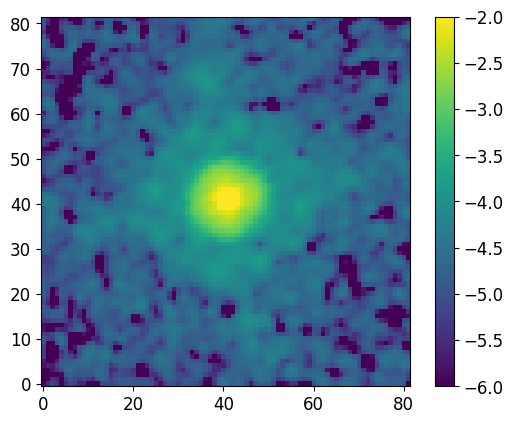

In [11]:
fig2 = pltf.single_PSF_plot(model, data_norm_F160, sigma_2_norm_F160, kwargs_final, masks=masks, n_psf=0, units='e-')
fig3 = pltf.multiple_PSF_plot(model, data_norm_F160, sigma_2_norm_F160, kwargs_final, masks=masks, units='e-', vmin=-5, vmax=5)
fig5 = plt.figure()
print(f"Overall Reduced Chi2 : {loss.reduced_chi2(kwargs_final)}")
full_psf = model.get_full_psf(**kwargs_final)
plt.imshow(np.nan_to_num(np.log10(full_psf), nan=-10), origin='lower', vmin=-6, vmax=-2)
plt.colorbar()

Overall Reduced Chi2:  1.3297408


/tmp/ipykernel_43965/4181556911.py:10: RuntimeWarning: invalid value encountered in log10
  im = ax.imshow(np.nan_to_num(np.log10(psf), nan=-10), origin='lower', vmin=-5, vmax=-2)


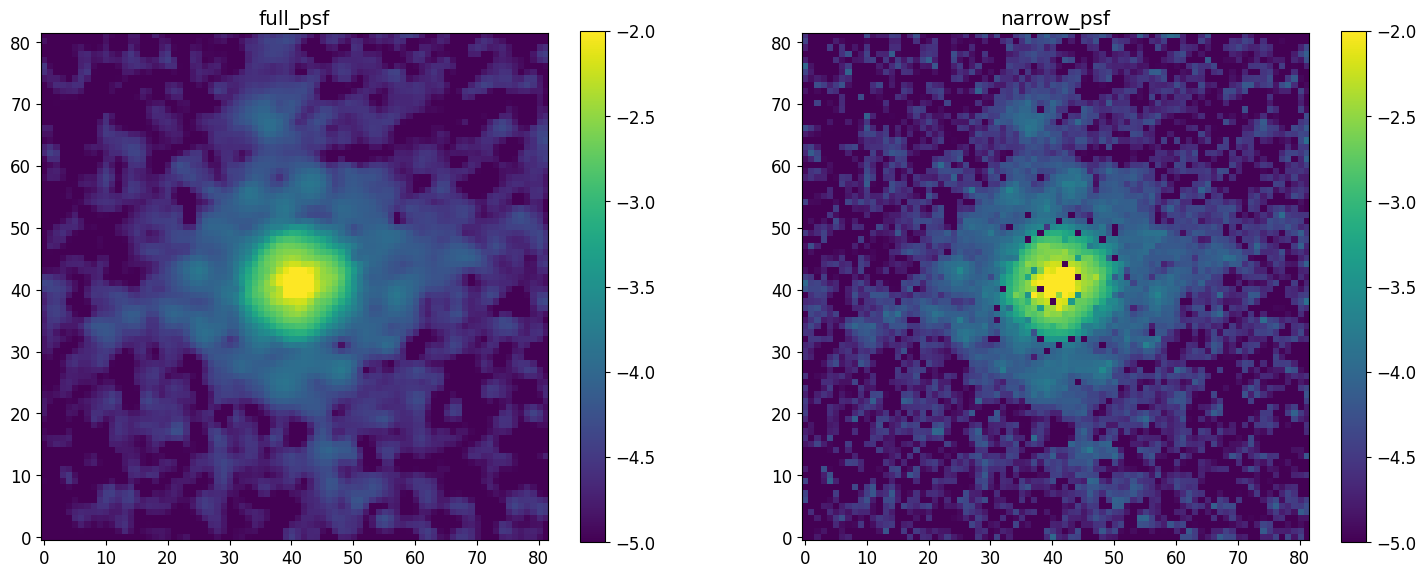

In [12]:
full_psf = model.get_full_psf(**kwargs_final)
s = model.get_narrow_psf(**kwargs_final, norm=True)
PSF_F160W = {"full_psf":full_psf,"narrow_psf":s,"full_psf_desnormalized":full_psf * norm_F160W / subsampling_factor**2}
#in my version this dosent work
print('Overall Reduced Chi2: ', loss.reduced_chi2(kwargs_final))

fig, axes = plt.subplots(1,2, figsize=(18, 8))
for ax, (key, psf) in zip(axes, PSF_F160W.items()):
    ax.set_title(key)
    im = ax.imshow(np.nan_to_num(np.log10(psf), nan=-10), origin='lower', vmin=-5, vmax=-2)
    fig.colorbar(im, ax=ax, shrink=0.83)
plt.show()

#### Method 2. (The best)

### Step 1, fixing : ['background'] ###


/home/felipe/miniconda3/envs/SFstarred/lib/python3.12/site-packages/starred/optim/optimization.py:181: UserWarning: You are using an unconstrained optimiser. Bounds are ignored.
  warnings.warn('You are using an unconstrained optimiser. Bounds are ignored.')


Step 1/2 took 134 seconds
Kwargs partial at step 1/2 {'kwargs_moffat': {'fwhm': Array([2.079524], dtype=float32), 'beta': Array([1.904953], dtype=float32), 'C': Array([45.19363], dtype=float32)}, 'kwargs_gaussian': {'a': Array([114.149506,  68.708244,  81.422745,  64.59074 ], dtype=float32), 'x0': Array([-0.04327326,  0.36285973, -0.12202075,  0.27896747], dtype=float32), 'y0': Array([ 0.16776209,  0.1812024 , -0.21203403, -0.37028927], dtype=float32)}, 'kwargs_background': {'background': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float32), 'mean': Array([0., 0., 0., 0.], dtype=float32)}, 'kwargs_distortion': {'dilation_x': Array([0., 0.], dtype=float32), 'dilation_y': Array([0., 0.], dtype=float32), 'shear': Array([0., 0.], dtype=float32)}}
LogL :  11174.045
Overall Reduced Chi2 :  3.3236303
### Step 2, fixing : ['moffat'] ###


optax.adabelief: 100%|██████████| 2000/2000 [00:21<00:00, 92.63it/s] 


Step 2/2 took 22 seconds
Kwargs partial at step 2/2 {'kwargs_moffat': {'fwhm': Array([2.079524], dtype=float32), 'beta': Array([1.904953], dtype=float32), 'C': Array([45.19363], dtype=float32)}, 'kwargs_gaussian': {'a': Array([119.285706,  72.602875,  83.78223 ,  67.79305 ], dtype=float32), 'x0': Array([-0.03122383,  0.37319505, -0.11037374,  0.3039185 ], dtype=float32), 'y0': Array([ 0.16268101,  0.15138382, -0.23094095, -0.38950595], dtype=float32)}, 'kwargs_background': {'background': Array([-0.00114763, -0.00299803, -0.00274291, ..., -0.00334555,
        0.00029406,  0.00314718], dtype=float32), 'mean': Array([0., 0., 0., 0.], dtype=float32)}, 'kwargs_distortion': {'dilation_x': Array([0., 0.], dtype=float32), 'dilation_y': Array([0., 0.], dtype=float32), 'shear': Array([0., 0.], dtype=float32)}}
LogL :  7143.3145
Overall Reduced Chi2 :  1.6224662
Moffat fit :


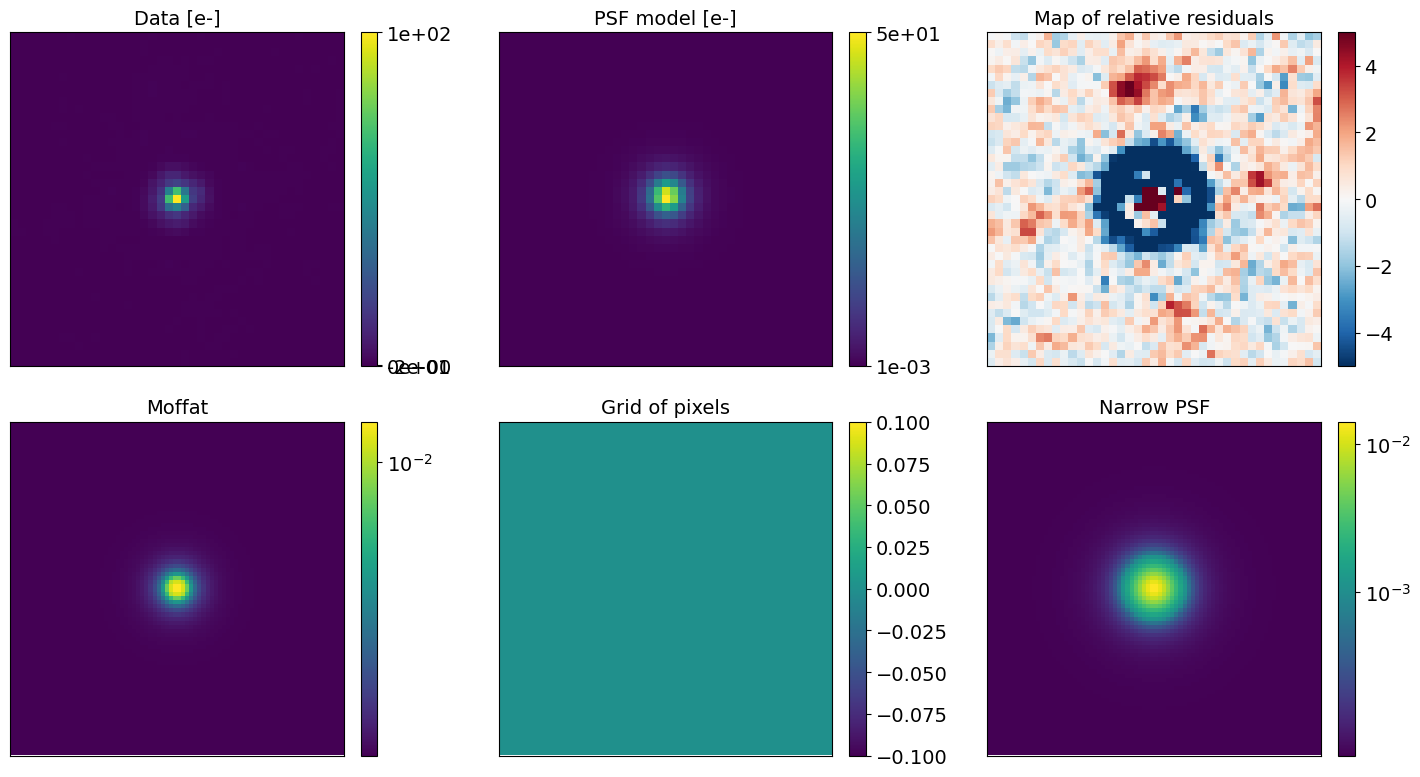

Moffat+ Background fit :


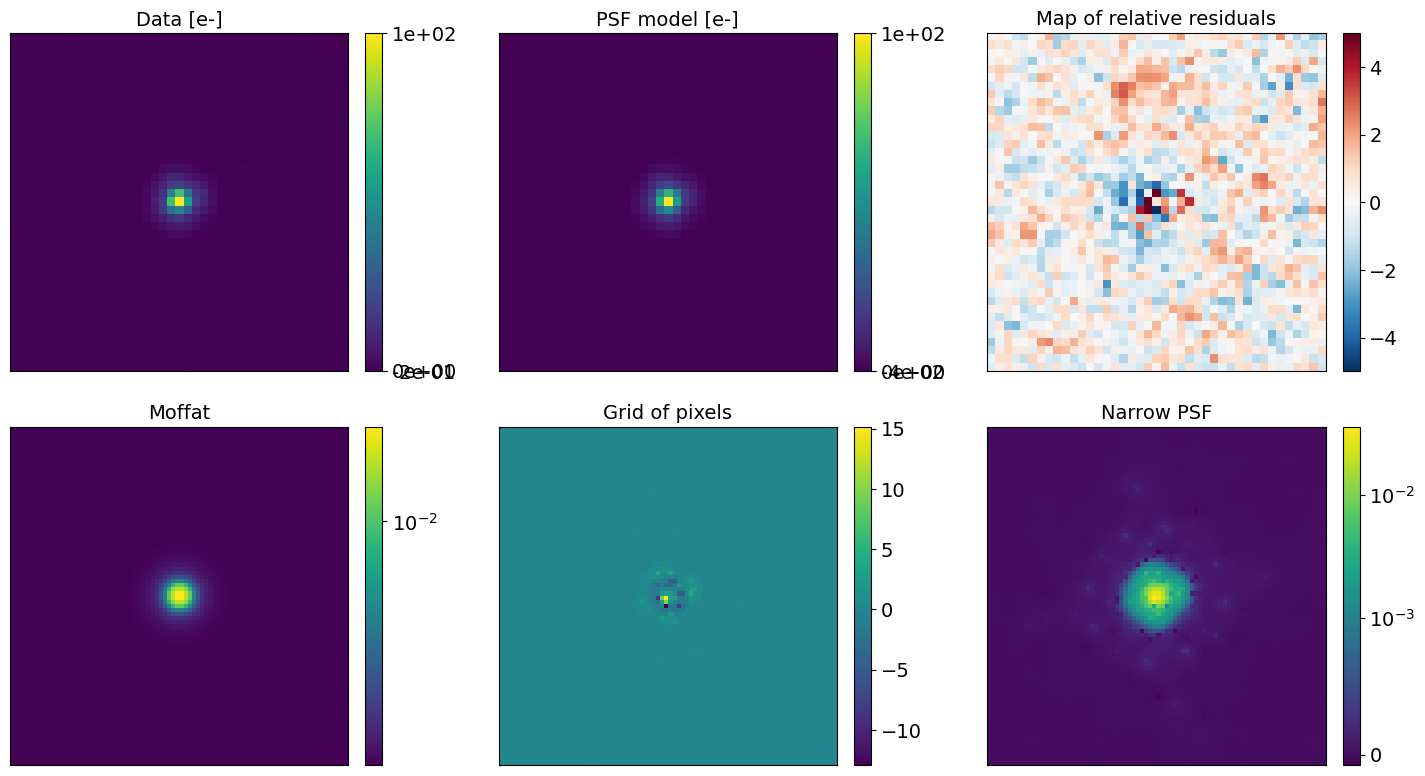

Multiple stars PSF model :


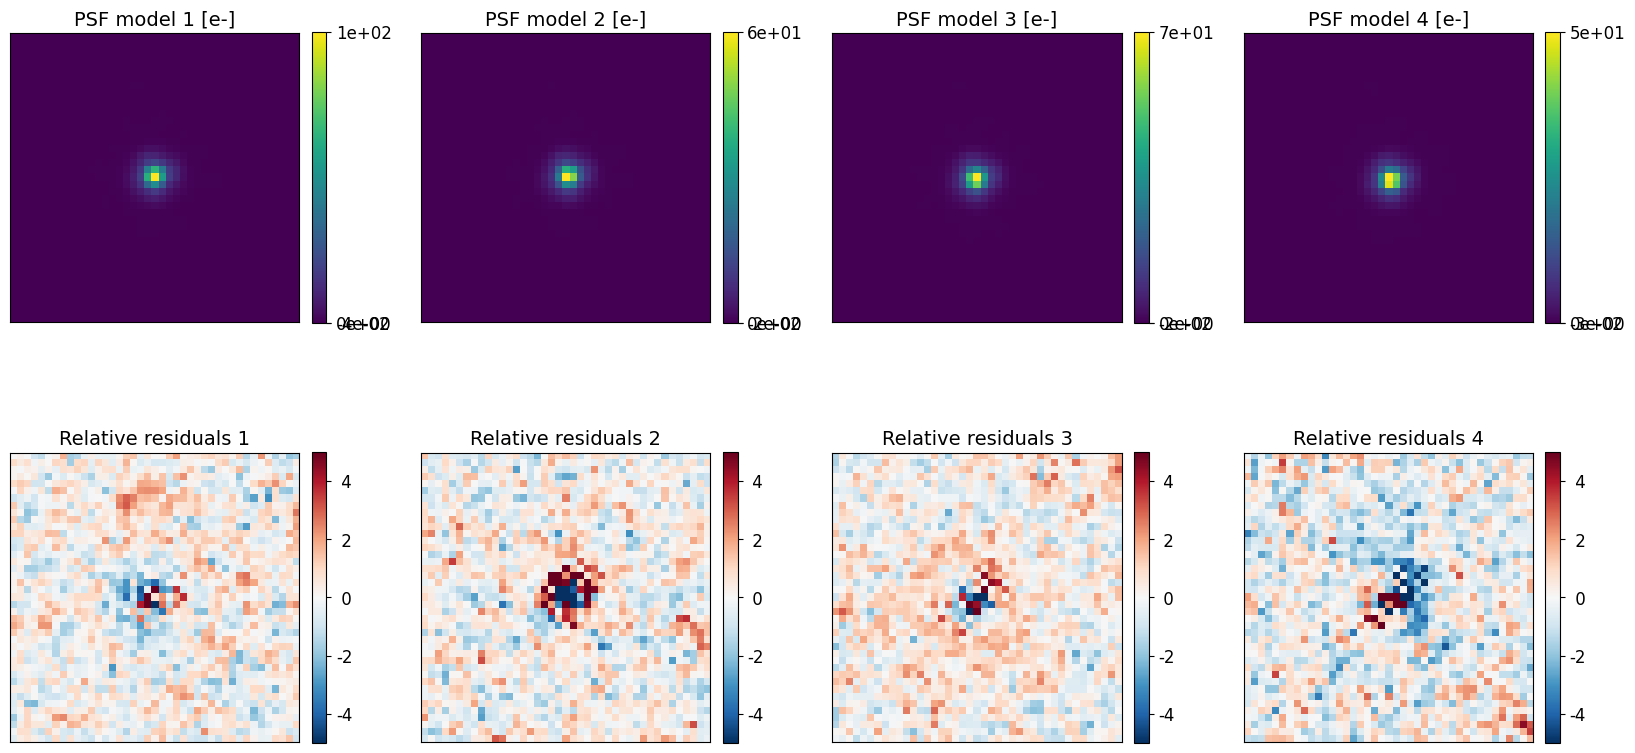

Loss history :


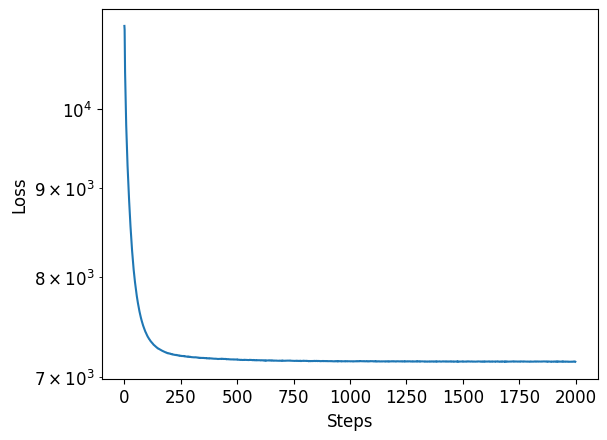

/tmp/ipykernel_43965/821709545.py:56: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.nan_to_num(np.log10(full_psf), nan=-10), origin='lower', vmin=-6, vmax=-2)


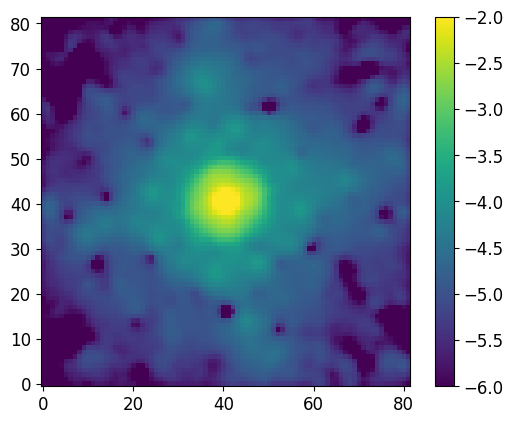

In [13]:
convolution_method = 'fft'
regularize_full_psf = False
include_moffat = True
model = PSF(image_size=image_size, number_of_sources=N, 
            upsampling_factor=subsampling_factor, 
            convolution_method=convolution_method,
            include_moffat = include_moffat)
kwargs_init, kwargs_fixed, kwargs_up, kwargs_down = model.smart_guess(data_norm_F160, fixed_background=False,
                                                                          guess_method='barycenter')
parameters = ParametersPSF(kwargs_init, kwargs_fixed, kwargs_up, kwargs_down)

fitting_sequence = [['background'], ['moffat']]
method_noise = "MC" # "SLIT" #
#'Newton-CG' reduce todo ? 
optim_list = ['Newton-CG', 'adabelief']
kwargs_optim_list = [{'maxiter': 1000}, \
                     {'max_iterations': 2000, 'min_iterations': None, \
                      'init_learning_rate': 0.01, \
                        'schedule_learning_rate': True, 'restart_from_init': False, \
                            'stop_at_loss_increase': False, 'progress_bar': True, \
                                'return_param_history': True}]
model, parameters, loss, kwargs_partial_list, LogL_list, loss_history_list = run_multi_steps_PSF_reconstruction(
        data_norm_F160, model,
        parameters, sigma_2_norm_F160, masks=None,
        lambda_scales=lambda_scales, lambda_hf=lambda_hf,
        lambda_positivity=lambda_positivity,
        fitting_sequence=fitting_sequence,
        optim_list=optim_list,
        kwargs_optim_list=kwargs_optim_list,
        method_noise=method_noise, regularize_full_psf=regularize_full_psf,
        verbose=True)


kwargs_final = kwargs_partial_list[-1]

fig1 = pltf.single_PSF_plot(model, data_norm_F160, sigma_2_norm_F160, kwargs_partial_list[0], n_psf=0, units='e-')
print('Moffat fit :')
plt.show(fig1)
fig2 = pltf.single_PSF_plot(model, data_norm_F160, sigma_2_norm_F160, kwargs_final, n_psf=0, units='e-')
print('Moffat+ Background fit :')
plt.show(fig2)
fig3 = pltf.multiple_PSF_plot(model,data_norm_F160, sigma_2_norm_F160, kwargs_final, units='e-')
print('Multiple stars PSF model :')
plt.show(fig3)

fig, ax = plt.subplots(1,1)
ax.plot(range(len(loss_history_list[-1])), loss_history_list[-1])
ax.set_xlabel('Steps')
ax.set_ylabel('Loss')
ax.set_yscale('log')
print('Loss history :')
plt.show(fig)
full_psf = model.get_full_psf(**kwargs_final)

fig5 = plt.figure()
plt.imshow(np.nan_to_num(np.log10(full_psf), nan=-10), origin='lower', vmin=-6, vmax=-2)
plt.colorbar()

Overall Reduced Chi2:  1.6224662


/tmp/ipykernel_43965/4181556911.py:10: RuntimeWarning: invalid value encountered in log10
  im = ax.imshow(np.nan_to_num(np.log10(psf), nan=-10), origin='lower', vmin=-5, vmax=-2)


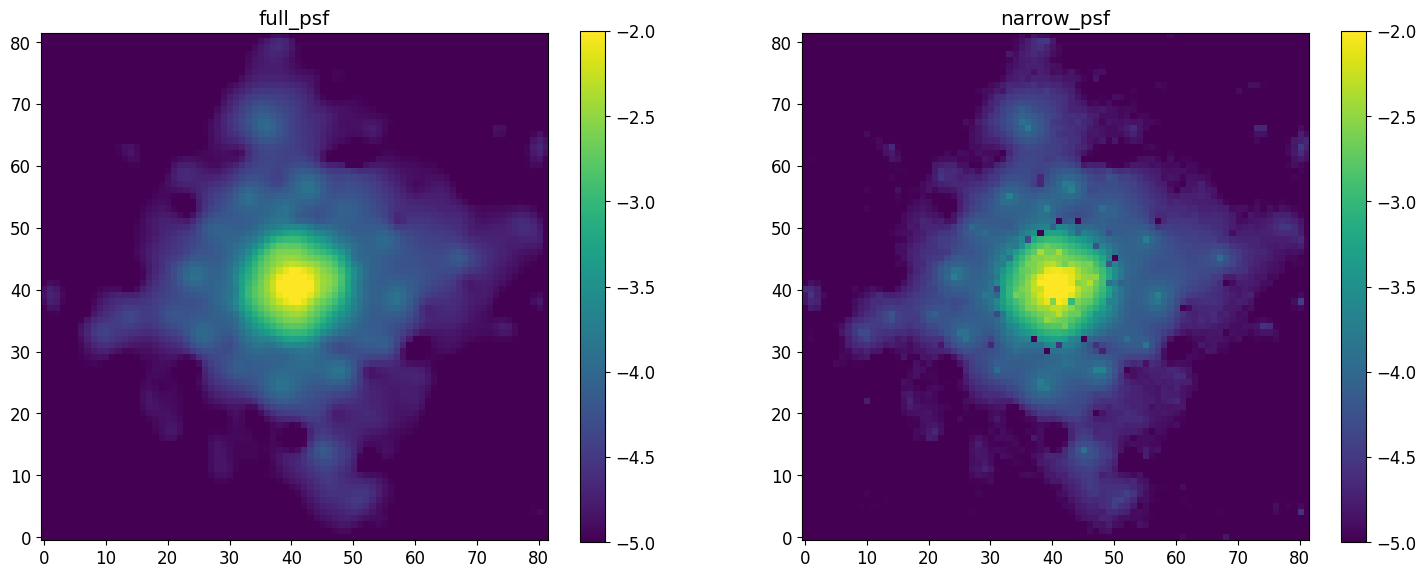

In [14]:
full_psf = model.get_full_psf(**kwargs_final)
s = model.get_narrow_psf(**kwargs_final, norm=True)
PSF_F160W = {"full_psf":full_psf,"narrow_psf":s,"full_psf_desnormalized":full_psf * norm_F160W / subsampling_factor**2}
#in my version this dosent work
print('Overall Reduced Chi2: ', loss.reduced_chi2(kwargs_final))

fig, axes = plt.subplots(1,2, figsize=(18, 8))
for ax, (key, psf) in zip(axes, PSF_F160W.items()):
    ax.set_title(key)
    im = ax.imshow(np.nan_to_num(np.log10(psf), nan=-10), origin='lower', vmin=-5, vmax=-2)
    fig.colorbar(im, ax=ax, shrink=0.83)
plt.show()

### Photometry and save  PSF 

#### Retrieve the different components of the model
 - `s` is the reconstructed "narrow" PSF, $s(x) = m(x) + h(x)$
 - `analytic` is the Moffat component, $m(x)$
 - `background` corresponds to the pixelated correction, $h(x)$
 - `full_psf` is the PSF of the original image, $t(x)$
 - `estimated_full_psf0` is the best fit PSF model for star 0.

In [15]:
estimated_full_psf0 = model.model(**kwargs_final)[0]
analytic = model.get_moffat(kwargs_final['kwargs_moffat'], norm=True)
s = model.get_narrow_psf(**kwargs_final, norm=True)
background = model.get_background(kwargs_final['kwargs_background'])

full_psf = model.get_full_psf(**kwargs_final)

print('Overall Reduced Chi2 : ', loss.reduced_chi2(kwargs_final))
result_psf_F160W = {"full_psf":full_psf,"narrow_psf":s,"analytic":analytic,"estimated_full_psf0":estimated_full_psf0,"background":background}
save_dict_as_h5py(result_psf_F160W,os.path.join(os.path.dirname(where_is_data),"result_psf_F160W"))

Overall Reduced Chi2 :  1.6224662


In [16]:
astrometry = model.get_astrometry(**kwargs_final)
photometry = model.get_photometry(**kwargs_final) * norm_F160W 
photometry_highres = model.get_photometry(**kwargs_final, high_res=True) * norm_F160W / subsampling_factor**2 # photometry on the subsampled PSF

print('Astrometry :', np.asarray(astrometry))
print('Photometry :', np.asarray(photometry))
print('Photometry high resolution :', np.asarray(photometry_highres))
[get_abmag(i,*list(header_values["F160W"].values())[:3]) for i in np.asarray(photometry)]


Astrometry : [[-0.03122383  0.16268101]
 [ 0.37319505  0.15138382]
 [-0.11037374 -0.23094095]
 [ 0.3039185  -0.38950595]]
Photometry : [106.300125  64.685905  74.65994   60.39773 ]
Photometry high resolution : [106.30015   64.685974  74.65993   60.39771 ]


[np.float64(20.871338128979765),
 np.float64(21.41064858430203),
 np.float64(21.254955530102812),
 np.float64(21.485119104321562)]

In [20]:
#Export the model
output_folder = os.path.join("data_products","F160W")

# Uncomment the following lines to save the obtained narrow PSF as a fits file
## model.export(output_folder, kwargs_final, new_vignets_data, sigma_2, format='fits') 
model.export(output_folder, kwargs_final, data_norm_F160, sigma_2_norm_F160, format='fits')

In [19]:
# from starred.procedures import build_psf
# narrow_psfs = []
# for star, noisemap in zip(stars, noisemaps):
#    narrow = build_psf(star, noisemap, subsampling_factor=2)['narrow_psf']
#    narrow_psfs.append(narrow)
# np.save('data_products/narrow_psfs.npy', narrow_psfs)

In [21]:
# #Save and Recover you model form the saved hdf5 file:
# hdf5_output=os.path.join(os.path.dirname(path_file), 'model_starred_save_F160.hdf5')
# model.dump(hdf5_output, kwargs_final, norm_F160W, data=data_norm_F160, sigma_2=sigma_2_norm_F160, masks=None, save_output_level=4, format='hdf5')
# #this is the way to read the files from starred
# model_rec, kwargs_final2_rec, norm_rec, data_rec, sigma_2_rec, masks_rec = load_PSF_model(hdf5_output, format='hdf5')

In [22]:

# #Save
# psf_filename = f'psf_f814w_{subsampling_factor*data_norm_F814W.shape[1]}x{subsampling_factor*data_norm_F814W.shape[1]}.hdf5'
# local_psf_filename = os.path.join(psf_filename)
# f = h5py.File(local_psf_filename, "w")
# dset = f.create_dataset('kernel_point_source', data=full_psf.copy())
# dset = f.create_dataset('psf_error_map', data=full_psf.copy()*0.1)
# f.close()

## ToDo: Deconvolving our object with our narrow PSFs

In [ ]:
#model_rec, kwargs_final2_rec, norm_rec, data_rec, sigma_2_rec, masks_rec = load_PSF_model(hdf5_output, format='hdf5')

In [45]:
obj_ = read_hdf5_to_dict("/home/favila/scripts_for_starred/notebooks/data_products/F160W/cut_out_F160W.hdf5")
data_ = obj_['system_cut_out']
noisemaps_ = obj_['sigma2']

In [48]:
data_

array([[0.06507871, 0.06553137, 0.07064795, ..., 0.05504537, 0.04739788,
        0.04495141],
       [0.05239975, 0.06538662, 0.06222051, ..., 0.07242051, 0.05521044,
        0.05512974],
       [0.05282381, 0.03670195, 0.06221375, ..., 0.06296822, 0.05192789,
        0.04565665],
       ...,
       [0.03952843, 0.04205835, 0.04583618, ..., 0.02687505, 0.04122853,
        0.02257581],
       [0.05288249, 0.04982236, 0.04673177, ..., 0.03400479, 0.03750508,
        0.0349963 ],
       [0.03367396, 0.04196006, 0.03603202, ..., 0.03001915, 0.02916873,
        0.04052663]], shape=(41, 41))

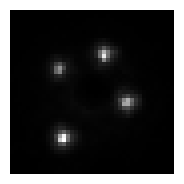

In [49]:
plt.figure(figsize=(2,2))
plt.imshow(data_/noisemaps_[0], cmap='gray', origin='lower')
plt.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
narrow_psfs = np.load('data/narrow_psfs.npy')
#object = np.load('data/object.npy', allow_pickle=True).item()

{'data_cutout': array([[[-5.06381691e-03,  2.96139717e-03,  6.08748198e-03, ...,
           7.60416687e-03,  1.30126029e-02, -7.25962222e-03],
         [-2.29777396e-03,  7.17556477e-03,  7.24653900e-03, ...,
           7.31793046e-03, -6.50873780e-03, -3.66432965e-03],
         [-1.22792423e-02,  2.82813609e-03,  1.00519359e-02, ...,
           9.19491053e-04,  1.08532608e-03,  1.24014765e-02],
         ...,
         [ 7.56785274e-04, -1.51009858e-03,  3.28363478e-03, ...,
          -1.32812560e-03, -5.51797450e-03,  5.49763441e-04],
         [ 7.20764697e-03,  2.88300216e-03,  7.36056268e-03, ...,
          -9.94528830e-03, -7.94464350e-03,  4.16296721e-03],
         [-3.12671065e-04,  1.24390423e-03, -8.76039267e-05, ...,
          -3.95242870e-03, -1.61473155e-02, -1.31389350e-02]],
 
        [[-6.52238727e-03,  4.13343310e-04, -7.92557001e-03, ...,
           6.91109896e-03, -4.35374677e-03, -1.74877048e-03],
         [-9.94080305e-03, -1.67452991e-02, -1.36351734e-02, ...,
      

In [ ]:
## Pixel position of lens galaxy (center of lens system)
qx = 1197.8 
qy = 1068.4
q_wcs = wcs.pixel_to_world(qx, qy) #convert lens coordinates to world coordinates
ra_q = q_wcs.ra #convert to RA, DEC
dec_q = q_wcs.dec
print(f"Lens RA: {ra_q}")
print(f"Lens Dec: {dec_q}")

#narrow psf is s
#narrow_psfs = np.load('data/narrow_psfs.npy')
object = np.load('data/object.npy', allow_pickle=True).item()
data = object['data']
noisemaps = object['noisemaps']
data.shape, noisemaps.shape
#object
cutout_system = Cutout2D(data_raw,wcs.all_world2pix(header["RA_TARG"]+shift[0], header["DEC_TARG"]+shift[1], 0), star_num_pix, wcs=wcs)
cutout_system_weight = Cutout2D(weights,wcs.all_world2pix(header["RA_TARG"]+shift[0], header["DEC_TARG"]+shift[1], 0), star_num_pix, wcs=wcs)


# F475X

In [ ]:
Data_F475X,path_file_F475X=data_for_starred('WG0214-2105_F475X_drc_sci.fits',remove_star=[],shift=[0,0],star_num_pix=41,make_plots=False,save=False)

In [ ]:
# Parameters
subsampling_factor = 3 #this can be increased for a better resolution, try 3 or 4 ! 
n_iter_initial = 100
n_iter = 4000 

lambda_scales = 3.0
lambda_hf = 3.0
lambda_positivity = 0. #penalising term if the full psf have negative pixels. Leave it to 0. in most cases to save computationnal time.
include_moffat = True

method1 = 'l-bfgs-b'
method2 = 'adabelief'

convolution_method = 'fft'
# Data 
print("F475X")
# Stars normalize, norm factor and sigma_2 normalize by norm**2
data_norm_F475X = Data_F475X["data_cutout_norm"]
norm_F475X=Data_F475X["norm"]
sigma_2_norm_F475X = Data_F475X['sigma2_norm']
# number of stars
N = len(data_norm_F475X)
# data dimensions
image_size = np.shape(data_norm_F475X)[1]
image_size_up = image_size * subsampling_factor
print(np.shape(data_norm_F475X))
fig = pltf.display_data(data_norm_F475X, sigma_2 = sigma_2_norm_F475X)

#### Method 1.

In [ ]:
# Build the PSF model class
include_moffat = True
elliptical = False # if you want to fit ellitpical moffat or simply circular 
model = PSF(image_size=image_size, number_of_sources=N, 
            upsampling_factor=subsampling_factor, 
            convolution_method=convolution_method,
            include_moffat = include_moffat,
            elliptical_moffat = elliptical)

# Parameter initialization. 
kwargs_init, kwargs_fixed, kwargs_up, kwargs_down = model.smart_guess(data_norm_F475X, fixed_background=True,guess_fwhm_pixels=3)
#reset the position to 0 as the JWST is too complex for barycentric estimates
kwargs_init['kwargs_gaussian']['x0'] = np.array([0. for i in range(N)])
kwargs_init['kwargs_gaussian']['y0'] = np.array([0. for i in range(N)])
##############################################################################

print('Initial Guess :', kwargs_init) 

parameters = ParametersPSF(kwargs_init, kwargs_fixed, kwargs_up=kwargs_up, kwargs_down=kwargs_down)

# Moffat fitting and amplitude tunning 
optim_method = 'l-bfgs-b'
loss = Loss(data_norm_F475X, model, parameters, sigma_2_norm_F475X, N, regularization_terms='l1_starlet', 
            regularization_strength_scales=0, regularization_strength_hf=0, masks = None) 
optim = Optimizer(loss, parameters, method=optim_method)

optimiser_options = {'maxiter':1000, 
                     'restart_from_init':True}

best_fit, logL_best_fit, extra_fields, runtime = optim.minimize(**optimiser_options)
# Printing partial results
kwargs_partial = parameters.args2kwargs(best_fit)
print('Moffat fit :',kwargs_partial) 

fig2 = pltf.single_PSF_plot(model, data_norm_F475X, sigma_2_norm_F475X, kwargs_partial,masks=None, n_psf=0, units='e-')
fig3 = pltf.multiple_PSF_plot(model, data_norm_F475X, sigma_2_norm_F475X, kwargs_partial,masks=None, units='e-')

In [ ]:
# compute noise level in starlet space, also propagate poisson noise
method_noise = "MC" #SLIT 
W = propagate_noise(model, np.sqrt(sigma_2_norm_F475X), kwargs_partial, masks=None, wavelet_type_list=['starlet'], method=method_noise, num_samples=500,
             seed=1, likelihood_type='chi2', verbose=False, upsampling_factor=subsampling_factor, scaling_noise_ref = None)[0]

#This is a representation of your noise maps (background + Poisson) in the different starlet scales
gix, axs = plt.subplots(1, len(W), figsize=(16, 4))
print('Mean noise level in each starlet scale: ')
for i, l in enumerate(W):
    axs[i].imshow(l, origin='lower')
    print('Scale %i :'%i, np.mean(l))
plt.show()

In [ ]:
regularize_full_psf = True #If True, regularise [m(x)+b(x)]. Regularise only the b(x) if False.
masks = None 
#  Release backgound, fix the moffat amplitude
kwargs_moffat_fixed = {'C':kwargs_partial['kwargs_moffat']['C']}

kwargs_fixed = {
    'kwargs_moffat': kwargs_moffat_fixed,
    'kwargs_gaussian': {},
    'kwargs_background': {},
}

parameters = ParametersPSF(kwargs_partial, kwargs_fixed, kwargs_up, kwargs_down)

loss = Loss(data_norm_F475X, model, parameters, sigma_2_norm_F475X, N, regularization_terms='l1_starlet',
            regularization_strength_scales=lambda_scales, regularization_strength_hf=lambda_hf,
            regularization_strength_positivity=lambda_positivity, W=W, regularize_full_psf=regularize_full_psf, masks=None)


optim = Optimizer(loss, parameters, method='adabelief')

kwargs_optim = {
                'max_iterations': 3000, 'min_iterations': None,
                'init_learning_rate': 1e-2, 'schedule_learning_rate': True,
                'restart_from_init': False, 'stop_at_loss_increase': False,
                'progress_bar': True, 'return_param_history': True
            }
best_fit, logL_best_fit, extra_fields, runtime = optim.minimize(**kwargs_optim)

In [ ]:
fig_loss = pltf.plot_loss(extra_fields['loss_history'])

kwargs_final = parameters.args2kwargs(best_fit)
print(kwargs_final)

In [ ]:
fig2 = pltf.single_PSF_plot(model, data_norm_F475X, sigma_2_norm_F475X, kwargs_final, masks=masks, n_psf=0, units='e-')
fig3 = pltf.multiple_PSF_plot(model, data_norm_F475X, sigma_2_norm_F475X, kwargs_final, masks=masks, units='e-', vmin=-5, vmax=5)
fig5 = plt.figure()
full_psf = model.get_full_psf(**kwargs_final)
print(f"Overall Reduced Chi2 : {loss.reduced_chi2(kwargs_final)}")
plt.imshow(np.nan_to_num(np.log10(full_psf), nan=-10), origin='lower', vmin=-6, vmax=-2)
plt.colorbar()

In [ ]:
PSF_F475X = {"full_psf":model.get_full_psf(**kwargs_final),"narrow_psf":model.get_narrow_psf(**kwargs_final, norm=True)}
fig, axes = plt.subplots(1,2, figsize=(18, 8))
for ax, (key, psf) in zip(axes, PSF_F475X.items()):
    ax.set_title(key)
    im = ax.imshow(np.nan_to_num(np.log10(psf), nan=-10), origin='lower', vmin=-4.5, vmax=-1.5)
    fig.colorbar(im, ax=ax, shrink=0.83)
plt.show()

### Method 2.

In [ ]:
convolution_method = 'fft'
regularize_full_psf = False
include_moffat = True
model = PSF(image_size=image_size, number_of_sources=N, 
            upsampling_factor=subsampling_factor, 
            convolution_method=convolution_method,
            include_moffat = include_moffat)
kwargs_init, kwargs_fixed, kwargs_up, kwargs_down = model.smart_guess(data_norm_F475X, fixed_background=False,
                                                                          guess_method='barycenter')
parameters = ParametersPSF(kwargs_init, kwargs_fixed, kwargs_up, kwargs_down)

fitting_sequence = [['background'], ['moffat']]
method_noise = "MC" # "SLIT" #
#'Newton-CG' reduce todo ? 
optim_list = ['Newton-CG', 'adabelief']
kwargs_optim_list = [{'maxiter': 1000}, \
                     {'max_iterations': 1000, 'min_iterations': None, \
                      'init_learning_rate': 0.01, \
                        'schedule_learning_rate': True, 'restart_from_init': False, \
                            'stop_at_loss_increase': False, 'progress_bar': True, \
                                'return_param_history': True}]
model, parameters, loss, kwargs_partial_list, LogL_list, loss_history_list = run_multi_steps_PSF_reconstruction(
        data_norm_F475X, model,
        parameters, sigma_2_norm_F475X, masks=None,
        lambda_scales=lambda_scales, lambda_hf=lambda_hf,
        lambda_positivity=lambda_positivity,
        fitting_sequence=fitting_sequence,
        optim_list=optim_list,
        kwargs_optim_list=kwargs_optim_list,
        method_noise=method_noise, regularize_full_psf=regularize_full_psf,
        verbose=True)


kwargs_final = kwargs_partial_list[-1]

fig1 = pltf.single_PSF_plot(model, data_norm_F475X, sigma_2_norm_F475X, kwargs_partial_list[0], n_psf=0, units='e-')
print('Moffat fit :')
plt.show(fig1)
fig2 = pltf.single_PSF_plot(model, data_norm_F475X, sigma_2_norm_F475X, kwargs_final, n_psf=0, units='e-')
print('Moffat+ Background fit :')
plt.show(fig2)
fig3 = pltf.multiple_PSF_plot(model,data_norm_F475X, sigma_2_norm_F475X, kwargs_final, units='e-')
print('Multiple stars PSF model :')
plt.show(fig3)

fig, ax = plt.subplots(1,1)
ax.plot(range(len(loss_history_list[-1])), loss_history_list[-1])
ax.set_xlabel('Steps')
ax.set_ylabel('Loss')
ax.set_yscale('log')
print('Loss history :')
plt.show(fig)
full_psf = model.get_full_psf(**kwargs_final)

fig5 = plt.figure()
plt.imshow(np.nan_to_num(np.log10(full_psf), nan=-10), origin='lower', vmin=-6, vmax=-2)
plt.colorbar()

In [ ]:
PSF_F475X = {"full_psf":model.get_full_psf(**kwargs_final),"narrow_psf":model.get_narrow_psf(**kwargs_final, norm=True)}
fig, axes = plt.subplots(1,2, figsize=(18, 8))
for ax, (key, psf) in zip(axes, PSF_F475X.items()):
    ax.set_title(key)
    im = ax.imshow(np.nan_to_num(np.log10(psf), nan=-10), origin='lower', vmin=-4.5, vmax=-1.5)
    fig.colorbar(im, ax=ax, shrink=0.83)
plt.show()

### Photometry and save  PSF 

#### Retrieve the different componenet of the model
 - `s` is the reconstructed "narrow" PSF, $s(x) = m(x) + h(x)$
 - `analytic` is the Moffat component, $m(x)$
 - `background` corresponds to the pixelated correction, $h(x)$
 - `full_psf` is the PSF of the original image, $t(x)$
 - `estimated_full_psf0` is the best fit PSF model for star 0.

In [ ]:
estimated_full_psf0 = model.model(**kwargs_final)[0]
analytic = model.get_moffat(kwargs_final['kwargs_moffat'], norm=True)
s = model.get_narrow_psf(**kwargs_final, norm=True)
background = model.get_background(kwargs_final['kwargs_background'])

full_psf = model.get_full_psf(**kwargs_final)

print('Overall Reduced Chi2 : ', loss.reduced_chi2(kwargs_final))
result_psf_F475W = {"full_psf":full_psf,"narrow_psf":s,"analytic":analytic,"estimated_full_psf0":estimated_full_psf0,"background":background}
#save_dict_as_h5py(result_psf_F475W,os.path.join(os.path.dirname(path_file_F475X),"result_psf_F475X"))

In [ ]:
astrometry = model.get_astrometry(**kwargs_final)
photometry = model.get_photometry(**kwargs_final) * norm_F475X
photometry_highres = model.get_photometry(**kwargs_final, high_res=True) * norm_F475X / subsampling_factor**2 # photometry on the subsampled PSF

print('Astrometry :', np.asarray(astrometry))
print('Photometry :', np.asarray(photometry))
print('Photometry high resolution :', np.asarray(photometry_highres))
[get_abmag(i,*list(header_values["F475X"].values())[:3]) for i in np.asarray(photometry)]

In [ ]:
# #Save and Recover you model form the saved hdf5 file:
# hdf5_output=os.path.join(os.path.dirname(path_file_F475X), 'model_starred_save_F475X.hdf5')
# model.dump(hdf5_output, kwargs_final, norm_F475X, data=data_norm_F475X, sigma_2=sigma_2_norm_F475X, masks=None, save_output_level=4, format='hdf5')
# #this is the way to read the files from starred
# model_rec, kwargs_final2_rec, norm_rec, data_rec, sigma_2_rec, masks_rec = load_PSF_model(hdf5_output, format='hdf5')

In [ ]:

# #Save
# psf_filename = f'psf_f814w_{subsampling_factor*data_norm_F814W.shape[1]}x{subsampling_factor*data_norm_F814W.shape[1]}.hdf5'
# local_psf_filename = os.path.join(psf_filename)
# f = h5py.File(local_psf_filename, "w")
# dset = f.create_dataset('kernel_point_source', data=full_psf.copy())
# dset = f.create_dataset('psf_error_map', data=full_psf.copy()*0.1)
# f.close()

# F814W

In [ ]:
Data_F814W,path_file_F814W=data_for_starred('WG0214-2105_F814W_drc_sci.fits',remove_star=[],shift=[0,0],star_num_pix=41,make_plots=False,save=False) 
#The chi2 in this case is under 1, the reason why is not clear for me I.

In [ ]:
#remove_star 3 (gives chi2~70 otherwise)
# Parameters
subsampling_factor = 3 #this can be increased fo a better resolution, try 3 or 4; should be 3 for lenstronomy
n_iter_initial = 100
n_iter = 1500 
#TENGO QUE INCREMENTAR EL NUMERO DE ITERACIONES
#TENGO QUE MODIFICAR LOS LAMBDA EN CASO DE NECESIDAD 
lambda_scales = 3.0
lambda_hf = 3.0 #increse this 
lambda_positivity = 0. #penalising term if the full psf have negative pixels. Leave it to 0. in most cases to save computationnal time.
# Stars normalize, norm factor and sigma_2 normalize by norm**2
data_norm_F814W = Data_F814W["data_cutout_norm"]
norm_F814W=Data_F814W["norm"]
sigma_2_norm_F814W = Data_F814W['sigma2_norm']
# number of stars
N = len(data_norm_F814W)
# data dimensions
image_size = np.shape(data_norm_F814W)[1]
image_size_up = image_size * subsampling_factor
print(np.shape(data_norm_F814W))
fig = pltf.display_data(data_norm_F814W, sigma_2 = sigma_2_norm_F814W)

### Method 1.

In [ ]:
# Build the PSF model class
convolution_method = 'fft'
include_moffat = True
elliptical = False # if you want to fit ellitpical moffat or simply circular 
model = PSF(image_size=image_size, number_of_sources=N, 
            upsampling_factor=subsampling_factor, 
            convolution_method=convolution_method,
            include_moffat = include_moffat,
            elliptical_moffat = elliptical)

# Parameter initialization. 
kwargs_init, kwargs_fixed, kwargs_up, kwargs_down = model.smart_guess(data_norm_F814W, fixed_background=True,guess_fwhm_pixels=3)
#reset the position to 0 as the JWST is too complex for barycentric estimates
kwargs_init['kwargs_gaussian']['x0'] = np.array([0. for i in range(N)])
kwargs_init['kwargs_gaussian']['y0'] = np.array([0. for i in range(N)])
##############################################################################

print('Initial Guess :', kwargs_init) 

parameters = ParametersPSF(kwargs_init, kwargs_fixed, kwargs_up=kwargs_up, kwargs_down=kwargs_down)

# Moffat fitting and amplitude tunning 
optim_method = 'l-bfgs-b'
loss = Loss(data_norm_F814W, model, parameters, sigma_2_norm_F814W, N, regularization_terms='l1_starlet', 
            regularization_strength_scales=0, regularization_strength_hf=0, masks = None) 
optim = Optimizer(loss, parameters, method=optim_method)

optimiser_options = {'maxiter':1000, 
                     'restart_from_init':True}

best_fit, logL_best_fit, extra_fields, runtime = optim.minimize(**optimiser_options)
# Printing partial results
kwargs_partial = parameters.args2kwargs(best_fit)
print('Moffat fit :',kwargs_partial) 

fig2 = pltf.single_PSF_plot(model, data_norm_F814W, sigma_2_norm_F814W, kwargs_partial,masks=None, n_psf=0, units='e-')
fig3 = pltf.multiple_PSF_plot(model, data_norm_F814W, sigma_2_norm_F814W, kwargs_partial,masks=None, units='e-')

In [ ]:
# compute noise level in starlet space, also propagate poisson noise
method_noise = "MC" #SLIT 
W = propagate_noise(model, np.sqrt(sigma_2_norm_F814W), kwargs_partial, masks=None, wavelet_type_list=['starlet'], method=method_noise, num_samples=500,
             seed=1, likelihood_type='chi2', verbose=False, upsampling_factor=subsampling_factor, scaling_noise_ref = None)[0]

#This is a representation of your noise maps (background + Poisson) in the different starlet scales
gix, axs = plt.subplots(1, len(W), figsize=(16, 4))
print('Mean noise level in each starlet scale: ')
for i, l in enumerate(W):
    axs[i].imshow(l, origin='lower')
    print('Scale %i :'%i, np.mean(l))
plt.show()

In [ ]:
regularize_full_psf = True #If True, regularise [m(x)+b(x)]. Regularise only the b(x) if False.
masks = None 
#  Release backgound, fix the moffat amplitude
kwargs_moffat_fixed = {'C':kwargs_partial['kwargs_moffat']['C']}

kwargs_fixed = {
    'kwargs_moffat': kwargs_moffat_fixed,
    'kwargs_gaussian': {},
    'kwargs_background': {},
}

parameters = ParametersPSF(kwargs_partial, kwargs_fixed, kwargs_up, kwargs_down)

loss = Loss(data_norm_F814W, model, parameters, sigma_2_norm_F814W, N, regularization_terms='l1_starlet',
            regularization_strength_scales=lambda_scales, regularization_strength_hf=lambda_hf,
            regularization_strength_positivity=lambda_positivity, W=W, regularize_full_psf=regularize_full_psf, masks=None)


optim = Optimizer(loss, parameters, method='adabelief')

kwargs_optim = {
                'max_iterations': 3000, 'min_iterations': None,
                'init_learning_rate': 1e-2, 'schedule_learning_rate': True,
                'restart_from_init': False, 'stop_at_loss_increase': False,
                'progress_bar': True, 'return_param_history': True
            }
best_fit, logL_best_fit, extra_fields, runtime = optim.minimize(**kwargs_optim)

In [ ]:
fig_loss = pltf.plot_loss(extra_fields['loss_history'])

kwargs_final = parameters.args2kwargs(best_fit)
print(kwargs_final)

In [ ]:
fig2 = pltf.single_PSF_plot(model, data_norm_F814W, sigma_2_norm_F814W, kwargs_final, masks=masks, n_psf=0, units='e-')
fig3 = pltf.multiple_PSF_plot(model, data_norm_F814W, sigma_2_norm_F814W, kwargs_final, masks=masks, units='e-', vmin=-5, vmax=5)
fig5 = plt.figure()
full_psf = model.get_full_psf(**kwargs_final)
print(f"Overall Reduced Chi2 : {loss.reduced_chi2(kwargs_final)}")
plt.imshow(np.nan_to_num(np.log10(full_psf), nan=-10), origin='lower', vmin=-6, vmax=-2)
plt.colorbar()

In [ ]:
PSF_F814W = {"full_psf":model.get_full_psf(**kwargs_final),"narrow_psf":model.get_narrow_psf(**kwargs_final, norm=True)}
fig, axes = plt.subplots(1,2, figsize=(18, 8))
print(f"Overall Reduced Chi2 : {loss.reduced_chi2(kwargs_final)}")
for ax, (key, psf) in zip(axes, PSF_F814W .items()):
    ax.set_title(key)
    im = ax.imshow(np.nan_to_num(np.log10(psf), nan=-10), origin='lower', vmin=-4.5, vmax=-1.5)
    fig.colorbar(im, ax=ax, shrink=0.83)
plt.show()

### Method 2.

In [ ]:
convolution_method = 'fft'
regularize_full_psf = False
include_moffat = True
model = PSF(image_size=image_size, number_of_sources=N, 
            upsampling_factor=subsampling_factor, 
            convolution_method=convolution_method,
            include_moffat = include_moffat)
kwargs_init, kwargs_fixed, kwargs_up, kwargs_down = model.smart_guess(data_norm_F814W, fixed_background=False,
                                                                          guess_method='barycenter')
parameters = ParametersPSF(kwargs_init, kwargs_fixed, kwargs_up, kwargs_down)

fitting_sequence = [['background'], ['moffat']]
method_noise = "MC" # "SLIT" #
#'Newton-CG' reduce todo ? 
optim_list = ['Newton-CG', 'adabelief']
kwargs_optim_list = [{'maxiter': 1000}, \
                     {'max_iterations': 1000, 'min_iterations': None, \
                      'init_learning_rate': 0.01, \
                        'schedule_learning_rate': True, 'restart_from_init': False, \
                            'stop_at_loss_increase': False, 'progress_bar': True, \
                                'return_param_history': True}]
model, parameters, loss, kwargs_partial_list, LogL_list, loss_history_list = run_multi_steps_PSF_reconstruction(
        data_norm_F814W, model,
        parameters, sigma_2_norm_F814W, masks=None,
        lambda_scales=lambda_scales, lambda_hf=lambda_hf,
        lambda_positivity=lambda_positivity,
        fitting_sequence=fitting_sequence,
        optim_list=optim_list,
        kwargs_optim_list=kwargs_optim_list,
        method_noise=method_noise, regularize_full_psf=regularize_full_psf,
        verbose=True)


kwargs_final = kwargs_partial_list[-1]

fig1 = pltf.single_PSF_plot(model, data_norm_F814W, sigma_2_norm_F814W, kwargs_partial_list[0], n_psf=0, units='e-')
print('Moffat fit :')
plt.show(fig1)
fig2 = pltf.single_PSF_plot(model, data_norm_F814W, sigma_2_norm_F814W, kwargs_final, n_psf=0, units='e-')
print('Moffat+ Background fit :')
plt.show(fig2)
fig3 = pltf.multiple_PSF_plot(model,data_norm_F814W, sigma_2_norm_F814W, kwargs_final, units='e-')
print('Multiple stars PSF model :')
plt.show(fig3)

fig, ax = plt.subplots(1,1)
ax.plot(range(len(loss_history_list[-1])), loss_history_list[-1])
ax.set_xlabel('Steps')
ax.set_ylabel('Loss')
ax.set_yscale('log')
print('Loss history :')
plt.show(fig)
full_psf = model.get_full_psf(**kwargs_final)

fig5 = plt.figure()
plt.imshow(np.nan_to_num(np.log10(full_psf), nan=-10), origin='lower', vmin=-6, vmax=-2)
plt.colorbar()

In [ ]:
PSF_F814W = {"full_psf":model.get_full_psf(**kwargs_final),"narrow_psf":model.get_narrow_psf(**kwargs_final, norm=True)}
fig, axes = plt.subplots(1,2, figsize=(18, 8))
print(f"Overall Reduced Chi2 : {loss.reduced_chi2(kwargs_final)}")
for ax, (key, psf) in zip(axes, PSF_F814W .items()):
    ax.set_title(key)
    im = ax.imshow(np.nan_to_num(np.log10(psf), nan=-10), origin='lower', vmin=-4.5, vmax=-1.5)
    fig.colorbar(im, ax=ax, shrink=0.83)
plt.show()

### Photometry and save  PSF 

#### Retrieve the different componenet of the model
 - `s` is the reconstructed "narrow" PSF, $s(x) = m(x) + h(x)$
 - `analytic` is the Moffat component, $m(x)$
 - `background` corresponds to the pixelated correction, $h(x)$
 - `full_psf` is the PSF of the original image, $t(x)$
 - `estimated_full_psf0` is the best fit PSF model for star 0.

In [ ]:
estimated_full_psf0 = model.model(**kwargs_final)[0]
analytic = model.get_moffat(kwargs_final['kwargs_moffat'], norm=True)
s = model.get_narrow_psf(**kwargs_final, norm=True)
background = model.get_background(kwargs_final['kwargs_background'])

full_psf = model.get_full_psf(**kwargs_final)

print('Overall Reduced Chi2 : ', loss.reduced_chi2(kwargs_final))
result_psf_F814W = {"full_psf":full_psf,"narrow_psf":s,"analytic":analytic,"estimated_full_psf0":estimated_full_psf0,"background":background}
#save_dict_as_h5py(result_psf_F814W,os.path.join(os.path.dirname(path_file_F814W),"result_psf_F814W"))

In [ ]:
astrometry = model.get_astrometry(**kwargs_final)
photometry = model.get_photometry(**kwargs_final) * norm_F814W
photometry_highres = model.get_photometry(**kwargs_final, high_res=True) * norm_F814W / subsampling_factor**2 # photometry on the subsampled PSF

print('Astrometry :', np.asarray(astrometry))
print('Photometry :', np.asarray(photometry))
print('Photometry high resolution :', np.asarray(photometry_highres))
[get_abmag(i,*list(header_values["F814W"].values())[:3]) for i in np.asarray(photometry)]

In [ ]:
# #Save and Recover you model form the saved hdf5 file:
# hdf5_output=os.path.join(os.path.dirname(path_filter_F814W), 'model_starred_save_F814W.hdf5')
# model.dump(hdf5_output, kwargs_final, norm_F814W, data=data_norm_F814W, sigma_2=sigma_2_norm_F814W, masks=None, save_output_level=4, format='hdf5')
# #this is the way to read the files from starred
# model_rec, kwargs_final2_rec, norm_rec, data_rec, sigma_2_rec, masks_rec = load_PSF_model(hdf5_output, format='hdf5')

In [ ]:
# #Save
# psf_filename = f'psf_f814w_{subsampling_factor*data_norm_F814W.shape[1]}x{subsampling_factor*data_norm_F814W.shape[1]}.hdf5'
# local_psf_filename = os.path.join(psf_filename)
# f = h5py.File(local_psf_filename, "w")
# dset = f.create_dataset('kernel_point_source', data=full_psf.copy())
# dset = f.create_dataset('psf_error_map', data=full_psf.copy()*0.1)
# f.close()